In [1]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import pylhe



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

In [3]:
import os
import sys
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
import concurrent.futures
import multiprocessing as mp
import contextlib
from tqdm import tqdm  

# --- LHAPDF Path Setup ---
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
E_BEAM = 6500.0    
PDF_NAME = 244600  
    

MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/nlo_MatrixElements/SubProcesses")
}

MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

PDG_MAP = {"uux": 2, "ddx": 1, "ssx": 3, "ccx": 4, "bbx": 5}

# ==========================================
# 2. HELPER FUNCTIONS & SILENCER
# ==========================================
@contextlib.contextmanager
def suppress_fortran_output():
    """Redirects OS-level C/Fortran stdout and stderr to the void."""
    devnull = os.open(os.devnull, os.O_WRONLY)
    old_stdout = os.dup(1)
    old_stderr = os.dup(2)
    try:
        os.dup2(devnull, 1)
        os.dup2(devnull, 2)
        yield
    finally:
        os.dup2(old_stdout, 1)
        os.dup2(old_stderr, 2)
        os.close(devnull)
        os.close(old_stdout)
        os.close(old_stderr)

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

def init_model_card(module, subproc_path, module_label):
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def eval_full_me(mod, subproc_path, p_fortran, alphas, scale2, nhel=-1):
    mod_attrs = dir(mod)
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
        res_arr = np.array(res)
        
        if res_arr.ndim == 2:
            if res_arr.shape[1] > 3:
                born_sm, born_bsm = float(res_arr[0, 3]), float(res_arr[0, 1])
            else:
                born_sm, born_bsm = float(res_arr[0, 0]), 0.0
            return {"born_sm": born_sm, "bsm_leading": born_bsm}
            
        elif res_arr.ndim == 1 and res_arr.size == 4:
            return {"born_sm": float(res_arr[0]), "bsm_leading": float(res_arr[1])}
        else:
            res_list = np.ravel(res_arr)
            finite_val = float(res_list[0]) if len(res_list) > 0 else 0.0
            return {"born_sm": 0.0, "bsm_leading": finite_val}
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. ISOLATED WORKER PROCESS
# ==========================================
def worker_evaluate_model(model_name, channel_paths, kinematics_list):
    """Runs entirely in isolated RAM. Saves directly to disk to avoid IPC freezing."""
    # This print will show up (before we silence)
    print(f"[{model_name}] OS Process started. Initializing and evaluating silently...")
    results = []
    
    # -----------------------------------------------------------------
    # THE SILENCER: Everything inside this block is absolutely muted
    # -----------------------------------------------------------------
    with suppress_fortran_output():
        loaded_modules = {}
        for ch_name, subproc_path in channel_paths.items():
            if subproc_path not in sys.path:
                sys.path.append(subproc_path)
                
            so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                       glob.glob(os.path.join(subproc_path, "*matrix*.so"))
            if not so_files: continue
                
            so_path = so_files[0]
            lib_name = os.path.basename(so_path).split(".")[0]
            
            spec = importlib.util.spec_from_file_location(lib_name, so_path)
            mod = importlib.util.module_from_spec(spec)
            sys.modules[lib_name] = mod
            spec.loader.exec_module(mod)
            
            init_model_card(mod, subproc_path, f"{model_name} | {ch_name}")
            loaded_modules[ch_name] = {"module": mod, "path": subproc_path}

        for idx, (P_fortran, alphas, scale_sq) in enumerate(kinematics_list):
            event_record = {"Event": idx}
            for ch_name, mod_dict in loaded_modules.items():
                try:
                    me_dict = eval_full_me(mod_dict["module"], mod_dict["path"], P_fortran, alphas, scale_sq, -1)
                    if model_name == "Zprime":
                        event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = me_dict["born_sm"]
                        event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
                    else:
                        event_record[f"ME_Born_{model_name}_{ch_name}"] = me_dict["born_sm"]
                        event_record[f"ME_Finite_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
                except Exception:
                    if model_name == "Zprime":
                        event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = np.nan
                        event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = np.nan
                    else:
                        event_record[f"ME_Born_{model_name}_{ch_name}"] = np.nan
                        event_record[f"ME_Finite_{model_name}_{ch_name}"] = np.nan
            results.append(event_record)
            
    df = pd.DataFrame(results)
    
    # Save directly to disk instead of returning the massive dataframe
    temp_file = f"temp_ME_{model_name}.pkl"
    df.to_pickle(temp_file)
    
    return temp_file

# ==========================================
# 4. MASTER PIPELINE ORCHESTRATOR
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path, model_path_dict):
    print(f"Processing LHE file: {lhe_path}")
    pdf = lhapdf.mkPDF(PDF_NAME) if isinstance(PDF_NAME, int) else lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    base_results, kinematics_list = [], []
    
    # --- PHASE 1: KINEMATICS ---
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Phase 1: Kinematics", mininterval=5.0)):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2: continue
            
        tops = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = tops[0], tops[1]
        
        E_tt, pz_tt = t.e + tbar.e, t.pz + tbar.pz
        x1, x2 = (E_tt + pz_tt) / (2.0 * E_BEAM), (E_tt - pz_tt) / (2.0 * E_BEAM)
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0): continue
            
        s_hat = E_tt**2 - (t.px + tbar.px)**2 - (t.py + tbar.py)**2 - pz_tt**2
        
        HT = sum(np.sqrt(p.m**2 + p.px**2 + p.py**2) for p in outgoing)
        dynamic_scale = HT / 2.0
        alphas = pdf.alphasQ(dynamic_scale)
        
        w_gg = (pdf.xfxQ(21, x1, dynamic_scale) / x1) * (pdf.xfxQ(21, x2, dynamic_scale) / x2)
        pdf_fluxes = {"w_gg": w_gg}
        for q_name, q_id in PDG_MAP.items():
            fq_1, fqbar_2 = pdf.xfxQ(q_id, x1, dynamic_scale) / x1, pdf.xfxQ(-q_id, x2, dynamic_scale) / x2
            fqbar_1, fq_2 = pdf.xfxQ(-q_id, x1, dynamic_scale) / x1, pdf.xfxQ(q_id, x2, dynamic_scale) / x2
            pdf_fluxes[f"w_{q_name}"] = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
        
        P_fortran = np.asfortranarray(invert_momenta([
            [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM],
            [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM],
            [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]
        ]), dtype=np.float64)
        
        base_results.append({"Event": idx, "x1": x1, "x2": x2, "s_hat": s_hat, 
                             "dynamic_scale": dynamic_scale, "alphas": alphas, 
                             "mg_weight": event.eventinfo.weight, **pdf_fluxes})
        kinematics_list.append((P_fortran, alphas, dynamic_scale**2))

    df_master = pd.DataFrame(base_results)
    
    # --- PHASE 2: MATRIX ELEMENTS (WITH DIRECT-TO-DISK WORKERS) ---
    print("\nPhase 2: Evaluating Fortran Matrix Elements in Background...")
    ctx = mp.get_context('fork')
    temp_files_created = []
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=len(model_path_dict), mp_context=ctx) as executor:
        futures = {
            executor.submit(worker_evaluate_model, m_name, ch_paths, kinematics_list): m_name 
            for m_name, ch_paths in model_path_dict.items()
        }
        
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Model Evaluation"):
            m_name = futures[future]
            try:
                temp_filename = future.result()
                temp_files_created.append(temp_filename)
                print(f"  -> Model [{m_name}] completed and saved to disk!")
            except Exception as exc:
                print(f"  -> Model [{m_name}] generated an exception: {exc}")

    # --- PHASE 3: MERGING FROM DISK ---
    print("\nPhase 3: Merging isolated results...")
    for temp_file in temp_files_created:
        df_model = pd.read_pickle(temp_file)
        df_master = pd.merge(df_master, df_model, on="Event")
        os.remove(temp_file)  # Clean up temporary file
    
    df_master = df_master.dropna().reset_index(drop=True)
    if output_csv_path:
        df_master.to_csv(output_csv_path, index=False, compression='infer')
        print(f"Successfully saved final merged data to: {output_csv_path}")
        
    return df_master

# ==========================================
# 5. EXECUTION BLOCK
# ==========================================
if __name__ == '__main__':
    model_path_dict = {}
    for m_name, root_dir in MODEL_ROOTS.items():
        model_path_dict[m_name] = {ch: os.path.join(root_dir, ch) for ch in MODEL_CHANNELS[m_name]}
    
    lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz"
    output_file   = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Final.csv.gz"

    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    df_mem = compute_matrix_elements(lhe_file_path, output_file, model_path_dict)
    
    print("\n" + "="*80)
    print(" DONE! Phase Space and Matrix Elements successfully compiled.")
    print("="*80)
    print(df_mem.head())

Processing LHE file: /home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600


Phase 1: Kinematics: 100%|████████| 3155536/3155536 [04:25<00:00, 11880.03it/s]



Phase 2: Evaluating Fortran Matrix Elements in Background...


Model Evaluation:   0%|                                  | 0/3 [00:00<?, ?it/s]

[VLF] OS Process started. Initializing and evaluating silently...
[Scalar] OS Process started. Initializing and evaluating silently...
[Zprime] OS Process started. Initializing and evaluating silently...


...

Model Evaluation:  67%|████████████████        | 2/3 [39:34<17:50, 1070.19s/it]

  -> Model [VLF] completed and saved to disk!


Model Evaluation: 100%|██████████████████████| 3/3 [1:53:21<00:00, 2267.31s/it]

  -> Model [Zprime] completed and saved to disk!



Phase 3: Merging isolated results...
Successfully saved final merged data to: /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Final.csv.gz

 DONE! Phase Space and Matrix Elements successfully compiled.
   Event        x1        x2         s_hat  dynamic_scale    alphas     mg_weight       w_gg     w_uux     w_ddx     w_ssx     w_ccx     w_bbx  ME_Born_Scalar_P0_uux_ttx  ME_Finite_Scalar_P0_uux_ttx  ME_Born_Scalar_P2_gg_ttx  ME_Finite_Scalar_P2_gg_ttx  ME_Born_VLF_P0_uux_ttx  ME_Finite_VLF_P0_uux_ttx  ME_Born_VLF_P2_gg_ttx  ME_Finite_VLF_P2_gg_ttx  ME_Born_SM_Zprime_P3_uux_ttx  ME_Born_NP_Zprime_P3_uux_ttx  ME_Born_SM_Zprime_P5_ddx_ttx  ME_Born_NP_Zprime_P5_ddx_ttx  ME_Born_SM_Zprime_P7_gg_ttx  ME_Born_NP_Zprime_P7_gg_ttx
0      0  0.051085  0.273962  2.365224e+06     225.103126  0.104218  5.527527e-07  13.862747  5.073260  2.613728  0.059012  0.034213  0.012155                   0.748708                     0.000571                 12.420180                   -0.000321              

In [16]:
import pandas as pd

# Path to your final CSV
csv_path = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

# Load ONLY the first 100 rows to save RAM and time
df_head = pd.read_csv(csv_path, nrows=100)

# Show all columns so they don't get hidden with '...'
pd.set_option('display.max_columns', None)

# Display the first 5 events
display(df_head.head())

,Event,x1,x2,s_hat,dynamic_scale,alphas,mg_weight,w_gg,w_uux,w_ddx,w_ssx,w_ccx,w_bbx,ME_Born_Scalar_P0_uux_ttx,ME_Finite_Scalar_P0_uux_ttx,ME_Born_VLF_P0_uux_ttx,ME_Finite_VLF_P0_uux_ttx,ME_Born_Scalar_P2_gg_ttx,ME_Finite_Scalar_P2_gg_ttx,ME_Born_SM_Zprime_P7_gg_ttx,ME_Born_NP_Zprime_P7_gg_ttx,ME_Born_VLF_P2_gg_ttx,ME_Finite_VLF_P2_gg_ttx,ME_Born_SM_Zprime_P3_uux_ttx,ME_Born_NP_Zprime_P3_uux_ttx,ME_Born_SM_Zprime_P5_ddx_ttx,ME_Born_NP_Zprime_P5_ddx_ttx
0,0,0.051085,0.273962,2.365224e+06,225.103126,0.104218,5.527527e-07,13.862747,5.073260,2.613728,0.059012,0.034213,0.012155,0.748708,0.000571,0.748708,0.000884,12.420180,-0.000321,12.420180,0.0,12.420180,0.000261,0.748708,0.000053,0.748708,0.000053
1,1,0.074593,0.201953,2.545869e+06,184.560007,0.106763,5.419669e-07,19.606602,4.836127,3.186983,0.143293,0.051476,0.017810,0.797170,0.000671,0.797170,0.001026,21.296750,-0.000546,21.296750,0.0,21.296750,0.000444,0.797170,0.000048,0.797170,0.000048
2,2,0.028864,0.509567,2.485691e+06,213.816214,0.104860,1.188034e-07,1.124798,1.730335,0.517565,-0.039211,0.000613,0.000320,0.761699,0.000621,0.761699,0.000953,14.781558,-0.000374,14.781558,0.0,14.781558,0.000311,0.761699,0.000049,0.761699,0.000049
3,3,0.058799,0.246377,2.448271e+06,175.466922,0.107465,2.729135e-07,16.672884,5.080911,2.877359,0.093129,0.040532,0.013898,0.809734,0.000647,0.809734,0.000995,22.937888,-0.000610,22.937888,0.0,22.937888,0.000474,0.809734,0.000051,0.809734,0.000051
4,4,0.070379,0.203715,2.422997e+06,205.623012,0.105350,6.113981e-07,21.138280,5.257941,3.412141,0.155541,0.057386,0.020204,0.770782,0.000607,0.770782,0.000936,15.756495,-0.000409,15.756495,0.0,15.756495,0.000329,0.770782,0.000051,0.770782,0.000051


In [4]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Final.csv"
OUTPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv"

# Looking at your data, normal values are ~0.00005. 
# We can safely define anything > 1.0 as a numerical instability.
ANOMALY_THRESHOLD = 1.0 

col_uu = "ME_Born_NP_Zprime_P3_uux_ttx"
col_dd = "ME_Born_NP_Zprime_P5_ddx_ttx"

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
original_len = len(df)

# ==========================================
# 3. IDENTIFY & FIX ANOMALIES
# ==========================================
# Create boolean masks for broken matrix elements
uu_broken = df[col_uu] > ANOMALY_THRESHOLD
dd_broken = df[col_dd] > ANOMALY_THRESHOLD

# Condition 1: dd is broken, uu is normal
mask_dd_bad_uu_good = dd_broken & ~uu_broken
df.loc[mask_dd_bad_uu_good, col_dd] = df.loc[mask_dd_bad_uu_good, col_uu]

# Condition 2: uu is broken, dd is normal
mask_uu_bad_dd_good = uu_broken & ~dd_broken
df.loc[mask_uu_bad_dd_good, col_uu] = df.loc[mask_uu_bad_dd_good, col_dd]

# Condition 3: Both are broken (we must drop these events entirely to be safe)
mask_both_broken = uu_broken & dd_broken
df = df[~mask_both_broken].reset_index(drop=True)

# ==========================================
# 4. PRINT SUMMARY & SAVE
# ==========================================
print("\n" + "="*50)
print("CLEANING SUMMARY:")
print("="*50)
print(f"Fixed {mask_dd_bad_uu_good.sum()} events where only dd was broken.")
print(f"Fixed {mask_uu_bad_dd_good.sum()} events where only uu was broken.")
print(f"Dropped {mask_both_broken.sum()} events where BOTH were broken.")
print("-" * 50)
print(f"Original events: {original_len}")
print(f"Final events   : {len(df)}")
print("="*50)

print(f"\nSaving cleaned dataset to {OUTPUT_CSV}...")
df.to_csv(OUTPUT_CSV, index=False)
print("Done!")

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Final.csv...

CLEANING SUMMARY:
Fixed 64 events where only dd was broken.
Fixed 0 events where only uu was broken.
Dropped 0 events where BOTH were broken.
--------------------------------------------------
Original events: 3155536
Final events   : 3155536

Saving cleaned dataset to /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv...
Done!


In [2]:
import pylhe
import itertools

lhe_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz"
E_BEAM = 6500.0  # Change to 6800.0 if you generated for 13.6 TeV

# Fast-forward directly to Event index 1 (the second event)
events_gen = pylhe.read_lhe_with_attributes(lhe_path)
event_1 = next(itertools.islice(events_gen, 1, 2))

# Identify the top quarks
outgoing = [p for p in event_1.particles if p.status == 1]
tops = sorted(outgoing, key=lambda x: x.id, reverse=True)
t, tbar = tops[0], tops[1]

# Reconstruct incoming partons based on x1, x2
E_tt, pz_tt = t.e + tbar.e, t.pz + tbar.pz
x1, x2 = (E_tt + pz_tt) / (2.0 * E_BEAM), (E_tt - pz_tt) / (2.0 * E_BEAM)

print("Copy this exact block for ./check:\n")
print(f"{x1*E_BEAM: .6e} {0.0: .6e} {0.0: .6e} {x1*E_BEAM: .6e}")
print(f"{x2*E_BEAM: .6e} {0.0: .6e} {0.0: .6e} {-x2*E_BEAM: .6e}")
print(f"{t.e: .6e} {t.px: .6e} {t.py: .6e} {t.pz: .6e}")
print(f"{tbar.e: .6e} {tbar.px: .6e} {tbar.py: .6e} {tbar.pz: .6e}")

Copy this exact block for ./check:

 4.848561e+02  0.000000e+00  0.000000e+00  4.848561e+02
 1.312693e+03  0.000000e+00  0.000000e+00 -1.312693e+03
 1.301465e+03 -6.375519e+01 -2.033893e+01 -1.288312e+03
 4.960844e+02  6.375519e+01  2.033893e+01  4.604751e+02


/tmp/ipykernel_149237/1914315336.py:9: DeprecationWarning: read_lhe_with_attributes is deprecated and will be removed in a future version. Use `LHEEvent.fromfile` with the `with_attributes` parameter instead.
  event_1 = next(itertools.islice(events_gen, 1, 2))


In [ ]:
import os
import sys
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
import concurrent.futures
from tqdm.notebook import tqdm
import multiprocessing as mp

# --- LHAPDF Path Setup ---
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
E_BEAM = 6500.0    
PDF_NAME = 244600  
MU_F  = 91.188     
MU_R  = 91.188    
MU_R2 = MU_R**2    

MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/nlo_MatrixElements/SubProcesses")
}

MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

PDG_MAP = {"uux": 2, "ddx": 1, "ssx": 3, "ccx": 4, "bbx": 5}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def eval_full_me(mod, subproc_path, p_fortran, alphas, scale2, nhel=-1):
    mod_attrs = dir(mod)
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
        res_arr = np.array(res)
        
        if res_arr.ndim == 2:
            if res_arr.shape[1] > 3:
                born_sm, born_bsm = float(res_arr[0, 3]), float(res_arr[0, 1])
            else:
                born_sm, born_bsm = float(res_arr[0, 0]), 0.0
            return {"born_sm": born_sm, "bsm_leading": born_bsm}
            
        elif res_arr.ndim == 1 and res_arr.size == 4:
            return {"born_sm": float(res_arr[0]), "bsm_leading": float(res_arr[1])}
        else:
            res_list = np.ravel(res_arr)
            finite_val = float(res_list[0]) if len(res_list) > 0 else 0.0
            return {"born_sm": 0.0, "bsm_leading": finite_val}
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. ISOLATED WORKER PROCESS
# ==========================================
def worker_evaluate_model(model_name, channel_paths, kinematics_list):
    """Runs entirely in isolated RAM. Loads libraries and evaluates events."""
    print(f"\n[{model_name}] OS Process started. Loading & Initializing modules...")
    
    loaded_modules = {}
    for ch_name, subproc_path in channel_paths.items():
        if subproc_path not in sys.path:
            sys.path.append(subproc_path)
            
        so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                   glob.glob(os.path.join(subproc_path, "*matrix*.so"))
                   
        if not so_files:
            continue
            
        so_path = so_files[0]
        lib_name = os.path.basename(so_path).split(".")[0]
        
        # Load the Fortran library
        spec = importlib.util.spec_from_file_location(lib_name, so_path)
        mod = importlib.util.module_from_spec(spec)
        sys.modules[lib_name] = mod
        spec.loader.exec_module(mod)
        
        # INITIALIZE FORTRAN PARAMETERS using your function!
        init_model_card(mod, subproc_path, f"{model_name} | {ch_name}")
        
        loaded_modules[ch_name] = {"module": mod, "path": subproc_path}
        print(f"  [{model_name}] [✓] Initialized {ch_name}")

    print(f"[{model_name}] Evaluating {len(kinematics_list)} events...")
    results = []
    
    for idx, (P_fortran, alphas, scale_sq) in enumerate(kinematics_list):
        event_record = {"Event": idx}
        for ch_name, mod_dict in loaded_modules.items():
            try:
                me_dict = eval_full_me(mod_dict["module"], mod_dict["path"], P_fortran, alphas, scale_sq, -1)
                if model_name == "Zprime":
                    event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = me_dict["born_sm"]
                    event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
                else:
                    event_record[f"ME_Born_{model_name}_{ch_name}"] = me_dict["born_sm"]
                    event_record[f"ME_Finite_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
            except Exception:
                if model_name == "Zprime":
                    event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = np.nan
                    event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = np.nan
                else:
                    event_record[f"ME_Born_{model_name}_{ch_name}"] = np.nan
                    event_record[f"ME_Finite_{model_name}_{ch_name}"] = np.nan
        results.append(event_record)
        
    return pd.DataFrame(results)

# ==========================================
# 4. MASTER PIPELINE ORCHESTRATOR
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path, model_path_dict):
    print(f"Processing LHE file: {lhe_path}")
    pdf = lhapdf.mkPDF(PDF_NAME) if isinstance(PDF_NAME, int) else lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    base_results, kinematics_list = [], []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Extracting Kinematics")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2: continue
            
        tops = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = tops[0], tops[1]
        
        E_tt, pz_tt = t.e + tbar.e, t.pz + tbar.pz
        x1, x2 = (E_tt + pz_tt) / (2.0 * E_BEAM), (E_tt - pz_tt) / (2.0 * E_BEAM)
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0): continue
            
        s_hat = E_tt**2 - (t.px + tbar.px)**2 - (t.py + tbar.py)**2 - pz_tt**2
        
        HT = sum(np.sqrt(p.m**2 + p.px**2 + p.py**2) for p in outgoing)
        dynamic_scale = HT / 2.0
        alphas = pdf.alphasQ(dynamic_scale)
        
        w_gg = (pdf.xfxQ(21, x1, dynamic_scale) / x1) * (pdf.xfxQ(21, x2, dynamic_scale) / x2)
        pdf_fluxes = {"w_gg": w_gg}
        for q_name, q_id in PDG_MAP.items():
            fq_1, fqbar_2 = pdf.xfxQ(q_id, x1, dynamic_scale) / x1, pdf.xfxQ(-q_id, x2, dynamic_scale) / x2
            fqbar_1, fq_2 = pdf.xfxQ(-q_id, x1, dynamic_scale) / x1, pdf.xfxQ(q_id, x2, dynamic_scale) / x2
            pdf_fluxes[f"w_{q_name}"] = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
        
        P_fortran = np.asfortranarray(invert_momenta([
            [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM],
            [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM],
            [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]
        ]), dtype=np.float64)
        
        base_results.append({"Event": idx, "x1": x1, "x2": x2, "s_hat": s_hat, 
                             "dynamic_scale": dynamic_scale, "alphas": alphas, 
                             "mg_weight": event.eventinfo.weight, **pdf_fluxes})
        kinematics_list.append((P_fortran, alphas, dynamic_scale**2))

    df_master = pd.DataFrame(base_results)
    model_dataframes = []
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=len(model_path_dict)) as executor:
        future_to_model = {
            executor.submit(worker_evaluate_model, m_name, ch_paths, kinematics_list): m_name 
            for m_name, ch_paths in model_path_dict.items()
        }
        for future in concurrent.futures.as_completed(future_to_model):
            try:
                model_dataframes.append(future.result())
            except Exception as exc:
                print(f"Process generated an exception: {exc}")

    for df_model in model_dataframes:
        df_master = pd.merge(df_master, df_model, on="Event")
    
    df_master = df_master.dropna().reset_index(drop=True)
    if output_csv_path:
        df_master.to_csv(output_csv_path, index=False, compression='infer')
        
    return df_master

# ==========================================
# 5. EXECUTION BLOCK
# ==========================================
if __name__ == '__main__':
    # Dynamically build the path dictionary (strings only!) to pass to the workers
    model_path_dict = {}
    for m_name, root_dir in MODEL_ROOTS.items():
        model_path_dict[m_name] = {ch: os.path.join(root_dir, ch) for ch in MODEL_CHANNELS[m_name]}
    
    lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz"
    output_file   = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels.csv.gz"

    df_mem = compute_matrix_elements(lhe_file_path, output_file, model_path_dict)
    print(df_mem.head())

In [5]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
from tqdm import tqdm

# --- LHAPDF Path Setup ---
# Replace with your actual LHAPDF installation path if different
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & MODEL REGISTRY SETUP
# ==========================================
E_BEAM = 6500.0    # Beam energy in GeV (e.g., 6500 for 13 TeV LHC)
PDF_NAME = 244600  # Must match the PDF set used in your MG5 event generation

# Fixed Renormalization & Factorization Scale 
MU_F  = 91.188     # Factorization scale in GeV (used ONLY for LHAPDF parton densities)
MU_R  = 91.188    # Renormalization scale in GeV (used for LHAPDF alpha_s)
MU_R2 = MU_R**2    # Renormalization scale squared in GeV^2 (used for MadLoop virtuals)   # Scale squared in GeV^2 (used for MadLoop virtuals)

# Define absolute root paths for all 3 model hypotheses
MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/nlo_MatrixElements/SubProcesses")
}

# Define production channels (using P1_ indexing for Zprime as confirmed earlier)
MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": [
        "P3_uux_ttx", 
        "P5_ddx_ttx", 
        "P7_gg_ttx"
    ]
}

# Map MadGraph directory prefixes to their corresponding PDG quark IDs for PDF lookup
PDG_MAP = {
    "uux": 2,  # Up
    "ddx": 1,  # Down
    "ssx": 3,  # Strange
    "ccx": 4,  # Charm
    "bbx": 5   # Bottom
}

# ==========================================
# 2. UNIVERSAL LIBRARY LOADER & INITIALIZER
# ==========================================

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p
def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def load_all_models(roots_dict, channels_dict):
    """Loads and compiles all matrix_*.so libraries into a unified dictionary registry."""
    registry = {}
    print("Loading Matrix Element Libraries...\n" + "="*50)
    for model_name, root_dir in roots_dict.items():
        print(f" -> Loading Model: [{model_name}]")
        registry[model_name] = {}
        for channel in channels_dict[model_name]:
            subproc_path = os.path.join(root_dir, channel)
            if subproc_path not in sys.path:
                sys.path.append(subproc_path)
            
            so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                       glob.glob(os.path.join(subproc_path, "*matrix*.so"))
            if not so_files:
                raise FileNotFoundError(f"No compiled .so library found in {subproc_path}")
            
            so_path = so_files[0]
            lib_name = os.path.basename(so_path).split(".")[0]  # Strip architecture tags
            
            spec = importlib.util.spec_from_file_location(lib_name, so_path)
            mod = importlib.util.module_from_spec(spec)
            sys.modules[lib_name] = mod
            spec.loader.exec_module(mod)
            
            init_model_card(mod, subproc_path, f"{model_name} | {channel}")
            registry[model_name][channel] = {
                "module": mod,
                "path": subproc_path
            }
            print(f"    [✓] {channel}")
    print("="*50 + "\n")
    return registry

# Initialize global model registry
models = load_all_models(MODEL_ROOTS, MODEL_CHANNELS)



Loading Matrix Element Libraries...
 -> Loading Model: [VLF]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Scalar]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Zprime]
    [✓] P3_uux_ttx
    [✓] P5_ddx_ttx
    [✓] P7_gg_ttx



In [64]:
import os
import sys
import numpy as np
import pandas as pd
import lhapdf
import pylhe
import importlib.util
import concurrent.futures
from tqdm.notebook import tqdm  # Use Jupyter-friendly tqdm

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

# ==========================================
# 1. EVALUATION WRAPPER
# ==========================================
def eval_full_me(mod, subproc_path, p_fortran, alphas, scale2, nhel=-1):
    mod_attrs = dir(mod)
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
        res_arr = np.array(res)
        
        if res_arr.ndim == 2:
            if res_arr.shape[1] > 3:
                born_sm = float(res_arr[0, 3])
                born_bsm = float(res_arr[0, 1])
            else:
                born_sm = float(res_arr[0, 0])
                born_bsm = 0.0
            return {"born_sm": born_sm, "bsm_leading": born_bsm}
            
        elif res_arr.ndim == 1 and res_arr.size == 4:
            born_val   = float(res_arr[0])
            finite_val = float(res_arr[1])
            return {"born_sm": born_val, "bsm_leading": finite_val}
            
        else:
            res_list = np.ravel(res_arr)
            born_val   = 0.0
            finite_val = float(res_list[0]) if len(res_list) > 0 else 0.0
            return {"born_sm": born_val, "bsm_leading": finite_val}
            
    finally:
        os.chdir(original_cwd)


# ==========================================
# 2. ISOLATED WORKER PROCESS
# ==========================================
def worker_evaluate_model(model_name, channel_paths, kinematics_list):
    """
    Runs in isolated RAM. Loads the Fortran module dynamically here to avoid Pickling errors.
    channel_paths is a dictionary like: {"P0_uux_ttx": "/path/to/folder"}
    """
    print(f"[{model_name}] OS Process started. Loading modules...")
    
    # Dynamically load the Fortran modules INSIDE the isolated process
    loaded_modules = {}
    for ch_name, path in channel_paths.items():
        sys.path.insert(0, path)
        # Find the .so file
        so_files = [f for f in os.listdir(path) if f.endswith('.so')]
        if not so_files:
            continue
        module_name = so_files[0].split('.')[0]
        
        spec = importlib.util.spec_from_file_location(module_name, os.path.join(path, so_files[0]))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        loaded_modules[ch_name] = {"module": mod, "path": path}
        sys.path.pop(0)

    print(f"[{model_name}] Evaluating {len(kinematics_list)} events...")
    results = []
    
    for idx, (P_fortran, alphas, scale_sq) in enumerate(kinematics_list):
        event_record = {"Event": idx}
        
        for ch_name, mod_dict in loaded_modules.items():
            try:
                me_dict = eval_full_me(mod_dict["module"], mod_dict["path"], P_fortran, alphas, scale_sq, -1)
                
                if model_name == "Zprime":
                    event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = me_dict["born_sm"]
                    event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
                else:
                    event_record[f"ME_Born_{model_name}_{ch_name}"] = me_dict["born_sm"]
                    event_record[f"ME_Finite_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
            except Exception as e:
                if model_name == "Zprime":
                    event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = np.nan
                    event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = np.nan
                else:
                    event_record[f"ME_Born_{model_name}_{ch_name}"] = np.nan
                    event_record[f"ME_Finite_{model_name}_{ch_name}"] = np.nan
                    
        results.append(event_record)
        
    print(f"[{model_name}] Process finished.")
    return pd.DataFrame(results)


# ==========================================
# 3. MASTER PIPELINE ORCHESTRATOR
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path, model_path_dict):
    print(f"Processing LHE file: {lhe_path}")
    
    if isinstance(PDF_NAME, int):
        pdf = lhapdf.mkPDF(PDF_NAME)
    else:
        pdf = lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    base_results = []
    kinematics_list = []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Extracting Kinematics")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2: continue
            
        tops = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = tops[0], tops[1]
        
        E_tt  = t.e + tbar.e
        pz_tt = t.pz + tbar.pz
        x1 = (E_tt + pz_tt) / (2.0 * E_BEAM)
        x2 = (E_tt - pz_tt) / (2.0 * E_BEAM)
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0): continue
            
        px_tt = t.px + tbar.px
        py_tt = t.py + tbar.py
        s_hat = E_tt**2 - px_tt**2 - py_tt**2 - pz_tt**2
        
        HT = sum(np.sqrt(p.m**2 + p.px**2 + p.py**2) for p in outgoing)
        dynamic_scale = HT / 2.0
        scale_sq = dynamic_scale**2
        alphas = pdf.alphasQ(dynamic_scale)
        
        w_gg = (pdf.xfxQ(21, x1, dynamic_scale) / x1) * (pdf.xfxQ(21, x2, dynamic_scale) / x2)
        pdf_fluxes = {"w_gg": w_gg}
        for q_name, q_id in PDG_MAP.items():
            fq_1    = pdf.xfxQ(q_id, x1, dynamic_scale) / x1
            fqbar_2 = pdf.xfxQ(-q_id, x2, dynamic_scale) / x2
            fqbar_1 = pdf.xfxQ(-q_id, x1, dynamic_scale) / x1
            fq_2    = pdf.xfxQ(q_id, x2, dynamic_scale) / x2
            pdf_fluxes[f"w_{q_name}"] = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
        
        mg_weight = event.eventinfo.weight
        
        p1 = [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM]
        p2 = [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM]
        p_list = [p1, p2, [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]]
        P_fortran = np.asfortranarray(invert_momenta(p_list), dtype=np.float64)
        
        base_results.append({
            "Event": idx, "x1": x1, "x2": x2, "s_hat": s_hat,
            "dynamic_scale": dynamic_scale, "alphas": alphas, 
            "mg_weight": mg_weight, **pdf_fluxes 
        })
        kinematics_list.append((P_fortran, alphas, scale_sq))

    df_master = pd.DataFrame(base_results)
    
    model_dataframes = []
    # Use ProcessPoolExecutor to safely spawn memory-isolated workers
    with concurrent.futures.ProcessPoolExecutor(max_workers=len(model_path_dict)) as executor:
        future_to_model = {
            executor.submit(worker_evaluate_model, m_name, ch_paths, kinematics_list): m_name 
            for m_name, ch_paths in model_path_dict.items()
        }
        
        for future in concurrent.futures.as_completed(future_to_model):
            try:
                model_dataframes.append(future.result())
            except Exception as exc:
                print(f"Process generated an exception: {exc}")

    for df_model in model_dataframes:
        df_master = pd.merge(df_master, df_model, on="Event")
    
    df_master = df_master.dropna().reset_index(drop=True)
    
    if output_csv_path:
        df_master.to_csv(output_csv_path, index=False, compression='infer')
        
    return df_master


# ==========================================
# 4. EXECUTION BLOCK (MANDATORY FOR JUPYTER)
# ==========================================
if __name__ == '__main__':
    # 1. Define globals needed
    PDF_NAME = "NNPDF23_nlo_as_0118_qed" # Replace with your integer or string
    E_BEAM = 6500.0
    PDG_MAP = {"uux": 2, "ddx": 1, "ccx": 4, "ssx": 3, "bbx": 5}
    
    # 2. IMPORTANT: Pass ONLY the string paths, NOT the loaded modules
    # The sub-processes will handle importing them.
    model_path_dict = {
        "VLF": {
            "P0_uux_ttx": "/home/vinicius/UnfoldingBSMttbar/VLF_matrix/P0_uux_ttx",
            "P2_gg_ttx": "/home/vinicius/UnfoldingBSMttbar/VLF_matrix/P2_gg_ttx"
        },
        "Scalar": {
            "P0_uux_ttx": "/home/vinicius/UnfoldingBSMttbar/Scalar_matrix/P0_uux_ttx",
            "P2_gg_ttx": "/home/vinicius/UnfoldingBSMttbar/Scalar_matrix/P2_gg_ttx"
        },
        "Zprime": {
            "P3_uux_ttx": "/home/vinicius/UnfoldingBSMttbar/Zprime_matrix/P3_uux_ttx",
            "P5_ddx_ttx": "/home/vinicius/UnfoldingBSMttbar/Zprime_matrix/P5_ddx_ttx",
            "P7_gg_ttx": "/home/vinicius/UnfoldingBSMttbar/Zprime_matrix/P7_gg_ttx"
        }
    }
    
    lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz"
    output_file   = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels.csv.gz"

    df_mem = compute_matrix_elements(lhe_file_path, output_file, model_path_dict)
    print(df_mem.head())

Processing LHE file: /home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz
Initializing LHAPDF with set 244600...
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600


Computing Raw MEs & Fluxes: 100%|█| 2855365/2855365 [2:37:28<00:00, 302.20it/s]



Successfully computed raw MEs for 2855365 events.
Saved raw ME dataframe to: /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels.csv.gz
   Event        x1        x2         s_hat  dynamic_scale    alphas     mg_weight       w_gg     w_uux     w_ddx     w_ssx     w_ccx     w_bbx  ME_Born_VLF_P0_uux_ttx  ME_Finite_VLF_P0_uux_ttx  ME_Born_VLF_P2_gg_ttx  ME_Finite_VLF_P2_gg_ttx  ME_Born_Scalar_P0_uux_ttx  ME_Finite_Scalar_P0_uux_ttx  ME_Born_Scalar_P2_gg_ttx  ME_Finite_Scalar_P2_gg_ttx  ME_Born_SM_Zprime_P3_uux_ttx  ME_Born_NP_Zprime_P3_uux_ttx  ME_Born_SM_Zprime_P5_ddx_ttx  ME_Born_NP_Zprime_P5_ddx_ttx  ME_Born_SM_Zprime_P7_gg_ttx  ME_Born_NP_Zprime_P7_gg_ttx
0      0  0.038595  0.263076  1.715907e+06     494.277411  0.095261  6.099611e-08  24.071092  8.635482  4.359647  0.126941  0.074627  0.029502                0.477495                  0.000396               0.884533                 0.000027                   0.477495                     0.000236                  0.884533              

In [33]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV  = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"
OUTPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Likelihoods_AllModels.csv.gz"

# Target artificial scale factors for the BSM models
Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

# --- MANUAL CROSS-SECTION INPUTS (in pb) ---
CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# --- LIKELIHOOD BASELINE --- (The denominator for your LLR)
BASELINE_MODEL = "Scalar"

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
original_len = len(df)

# Filter out negative weights entirely
df = df[df["mg_weight"] >= 0].reset_index(drop=True)

# Compute the normalized event weight w_i (sum of w_i will exactly equal 1.0)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

print(f"Loaded {original_len} events. Kept {len(df)} events with positive weights.")
print("Computing likelihoods...")

# ==========================================
# 3. PASS 1: COMPUTE RAW PROBABILITIES
# ==========================================
for model, channels in MODELS.items():
    y_dm = Y_DM_CONFIG[model]["y_dm"]
    scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        # ---------------------------------------------------------
        # FLAVOR SYMMETRY FIX:
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"])
        else:
            flux = df[f"w_{parton_pair}"]
            
        # Select the correct column names
        if model == "Zprime":
            sm_col  = f"ME_Born_SM_{model}_{ch}"
            bsm_col = f"ME_Born_NP_{model}_{ch}"
        else:
            sm_col  = f"ME_Born_{model}_{ch}"
            bsm_col = f"ME_Finite_{model}_{ch}"
            
        # Compute probabilities
        p_sm_total += flux * df[sm_col]
        p_bsm_leading += flux * df[bsm_col]
        
    p_model_total = p_sm_total + (scale_factor * p_bsm_leading)
    
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_Leading_{model}"] = p_bsm_leading
    df[f"P_Total_{model}"] = p_model_total

# ==========================================
# 4. PASS 2: EXACT REWEIGHTING & NORMALIZATION (LLR)
# ==========================================
epsilon = 1e-300  # Safeguard against log(0)

# Define the physical Baseline for the Log-Likelihood Ratios
p_baseline = df[f"P_Total_{BASELINE_MODEL}"]
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]

# SAFEGUARD: Clip baseline probabilities to strictly be >= epsilon
p_baseline_safe = np.clip(p_baseline, a_min=epsilon, a_max=None)

# Precompute the logs for the baseline denominator
log_p_baseline = np.log(p_baseline_safe)
log_p_norm_baseline = np.log(p_baseline_safe / sigma_baseline)

print("\n" + "="*60)
print(f"Baseline Denominator: {BASELINE_MODEL} (y_dm = {Y_DM_CONFIG[BASELINE_MODEL]['y_dm']})")
print(f"Baseline Total Cross-Section: {sigma_baseline:.6e}")
print("="*60)

for model in MODELS.keys():
    p_target = df[f"P_Total_{model}"]
    sigma_target = CROSS_SECTIONS[model]
    
    # SAFEGUARD: Clip target probabilities to strictly be >= epsilon
    p_target_safe = np.clip(p_target, a_min=epsilon, a_max=None)
    
    # LOG-LIKELIHOOD RATIO (TARGET vs BASELINE)
    log_p_target = np.log(p_target_safe)
    log_p_norm_target = np.log(p_target_safe / sigma_target)
    
    llr_unnorm = log_p_target - log_p_baseline
    llr_norm = log_p_norm_target - log_p_norm_baseline
    
    df[f"LLR_Unnorm_{model}"] = llr_unnorm
    df[f"LLR_Norm_{model}"] = llr_norm
    df[f"P_Total_Norm_{model}"] = np.where(sigma_target > 0, p_target / sigma_target, 0)
    
    # NEW: Store the per-event weighted LLR
    df[f"Weighted_LLR_{model}"] = df["w_i"] * llr_norm

# ==========================================
# 5. COMPUTE BASE EXPECTED LLR (PER EVENT)
# ==========================================
print("\n" + "="*60)
print("COMPUTING EXPECTED LLR (PER SINGLE OBSERVED EVENT)")
print("="*60)

for model in MODELS.keys():
    
    # Filter out any lingering NaNs just to be perfectly safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # Calculate the Expected LLR for 1 event by summing the new weighted column
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
        
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (per event) : {llr_1event:.6e}")
    print("-" * 60)

# ==========================================
# 6. SAVE RESULTS
# ==========================================
df.to_csv(OUTPUT_CSV, index=False, compression='infer')
print(f"\nSuccess! Likelihood dataset saved to: {OUTPUT_CSV}")

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155536 events. Kept 3155491 events with positive weights.
Computing likelihoods...

Baseline Denominator: Scalar (y_dm = 4.430268)
Baseline Total Cross-Section: 1.261259e+00

COMPUTING EXPECTED LLR (PER SINGLE OBSERVED EVENT)
Model: VLF [y_dm=2.715766]
  -> Expected LLR (per event) : -1.496146e-03
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (per event) : 0.000000e+00
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (per event) : -2.786289e-03
------------------------------------------------------------

Success! Likelihood dataset saved to: /home/vinicius/UnfoldingBSMttbar/Likelihoods_AllModels.csv.gz


In [10]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
INPUT_CSV  = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
LUMI_FB = 500.0 
LUMI_PB = LUMI_FB * 1000.0 
EPSILON = 1e-300

print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
df = df[df["mg_weight"] >= 0].reset_index(drop=True)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

if "sqrt_s_hat" not in df.columns:
    df["sqrt_s_hat"] = np.sqrt(df["s_hat"])


# ==========================================
# 2. RAW PROBABILITIES & SYSTEMATICS
# ==========================================

# -- Option 1: Scale-dependent shape error (from invariant mass) --
x_val = np.minimum(df["sqrt_s_hat"].values, 2750.0)
df["sys_shape"] = ((1.43e-06 * (x_val**2)) + (6.18e-03 * x_val) + 4.81) / 100.0

# -- Option 2: Flat systematic error (e.g., 10%) --
df["sys_flat"] = 0.1 

# --- SWITCH SYSTEMATIC ERROR HERE ---
ACTIVE_SYS = "sys_shape"  # Change to "sys_flat" to use the constant 10% error
deltas = df[ACTIVE_SYS].values

print(f"Applying systematic error: {ACTIVE_SYS}")

for model, channels in MODELS.items():
    scale_factor = Y_DM_CONFIG[model]["y_dm"] ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"])
        else:
            flux = df[f"w_{parton_pair}"]
            
        if model == "Zprime":
            p_sm_total += flux * df[f"ME_Born_SM_{model}_{ch}"]
            p_bsm_leading += flux * df[f"ME_Born_NP_{model}_{ch}"]
        else:
            p_sm_total += flux * df[f"ME_Born_{model}_{ch}"]
            p_bsm_leading += flux * df[f"ME_Finite_{model}_{ch}"]
            
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_{model}"] = p_bsm_leading * scale_factor

# ==========================================
# 3. EXACT EVENT-BY-EVENT PROFILING
# ==========================================
def profile_events_analytically(p_sm, p_bsm, sys_array):
    """
    Computes the exact event-by-event optimal nuisance parameters (theta_i) 
    using the analytical quadratic solution.
    """
    A = p_sm * sys_array
    B = p_sm + p_bsm
    
    # Safe division mapping to avoid divide-by-zero where A is 0
    theta_i = np.where(
        A > 1e-12, 
        (-B + np.sqrt(B**2 + 4 * A**2)) / (2 * A), 
        0.0
    )
    
    p_prof = B + (A * theta_i)
    
    # The penalty is strictly the squared shift (we apply the weights in Step 4)
    raw_penalty = 0.5 * (theta_i**2)
    
    return np.clip(p_prof, EPSILON, None), raw_penalty, theta_i

# ==========================================
# 4. COMPUTE JOINT LLR
# ==========================================
print("\n" + "="*60)
print("COMPUTING EVENT-BY-EVENT PROFILED JOINT LLR")
print("="*60)

sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_EVENTS_BASE = sigma_baseline * LUMI_PB
w_i = df["w_i"].values

# FIXED: Correctly assign the full BSM component to the Baseline Model
p_sm_base = df[f"P_SM_{BASELINE_MODEL}"].values
p_bsm_base = df[f"P_BSM_{BASELINE_MODEL}"].values  

p_prof_base, raw_penalty_base, thetas_base = profile_events_analytically(p_sm_base, p_bsm_base, deltas)

# Normalize baseline cross-section dynamically based on the shifted weights
sigma_prof_base = sigma_baseline * np.sum(w_i * (p_prof_base / np.clip(p_sm_base + p_bsm_base, EPSILON, None)))
log_p_base = np.log(p_prof_base / sigma_prof_base)

# FIXED: Multiply the raw penalty by the expected physical event yield (N * w_i)
weighted_penalty_base = N_EVENTS_BASE * w_i * raw_penalty_base
nll_base_total = -np.sum(N_EVENTS_BASE * w_i * log_p_base) + np.sum(weighted_penalty_base)

for model in MODELS.keys():
    if model == BASELINE_MODEL:
        # We can still print the baseline vs baseline validation check
        print(f"Model: {model} [BASELINE]")
        print(f"  -> Profiled Joint LLR       : 0.00")
        print(f"  -> Avg Baseline Nuisance    : {np.mean(thetas_base):+.5f} sigma")
        print("-" * 60)
        continue
        
    p_sm_target = df[f"P_SM_{model}"].values
    p_bsm_target = df[f"P_BSM_{model}"].values
    sigma_target = CROSS_SECTIONS[model]
    
    # Profile the Target Model
    p_prof_target, raw_penalty_target, thetas_target = profile_events_analytically(p_sm_target, p_bsm_target, deltas)
    
    # Normalize target cross-section dynamically
    sigma_prof_target = sigma_target * np.sum(w_i * (p_prof_target / np.clip(p_sm_target + p_bsm_target, EPSILON, None)))
    log_p_target = np.log(p_prof_target / sigma_prof_target)
    
    # FIXED: Multiply the raw penalty by the expected physical event yield
    weighted_penalty_target = N_EVENTS_BASE * w_i * raw_penalty_target
    nll_target_total = -np.sum(N_EVENTS_BASE * w_i * log_p_target) + np.sum(weighted_penalty_target)
    
    # Profiled LLR
    joint_llr = -(nll_target_total - nll_base_total)
    significance = np.sqrt(-2 * joint_llr) if joint_llr < 0 else 0.0
    
    print(f"Model: {model}")
    print(f"  -> Profiled Joint LLR       : {joint_llr:.2f}")
    print(f"  -> Avg Target Nuisance      : {np.mean(thetas_target):+.5f} sigma")
    print(f"  -> Profiled Significance    : {significance:.2f} sigma")
    print("-" * 60)

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Applying systematic error: sys_shape

COMPUTING EVENT-BY-EVENT PROFILED JOINT LLR
Model: VLF
  -> Profiled Joint LLR       : -995.23
  -> Avg Target Nuisance      : +0.19807 sigma
  -> Profiled Significance    : 44.61 sigma
------------------------------------------------------------
Model: Scalar [BASELINE]
  -> Profiled Joint LLR       : 0.00
  -> Avg Baseline Nuisance    : +0.19733 sigma
------------------------------------------------------------
Model: Zprime
  -> Profiled Joint LLR       : -1864.18
  -> Avg Target Nuisance      : +0.19880 sigma
  -> Profiled Significance    : 61.06 sigma
------------------------------------------------------------


In [ ]:
6

In [36]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -1.496146e-03
  -> Total Log-Likelihood    : -943.51
  -> Asimov Significance     : 43.44 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -2.786289e-03
  -> Total Log-Likelihood    : -1757.12
  -> Asimov Significance     : 59.28 sigma
------------------------------------------------------------


Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155536 events.
Computing and plotting...


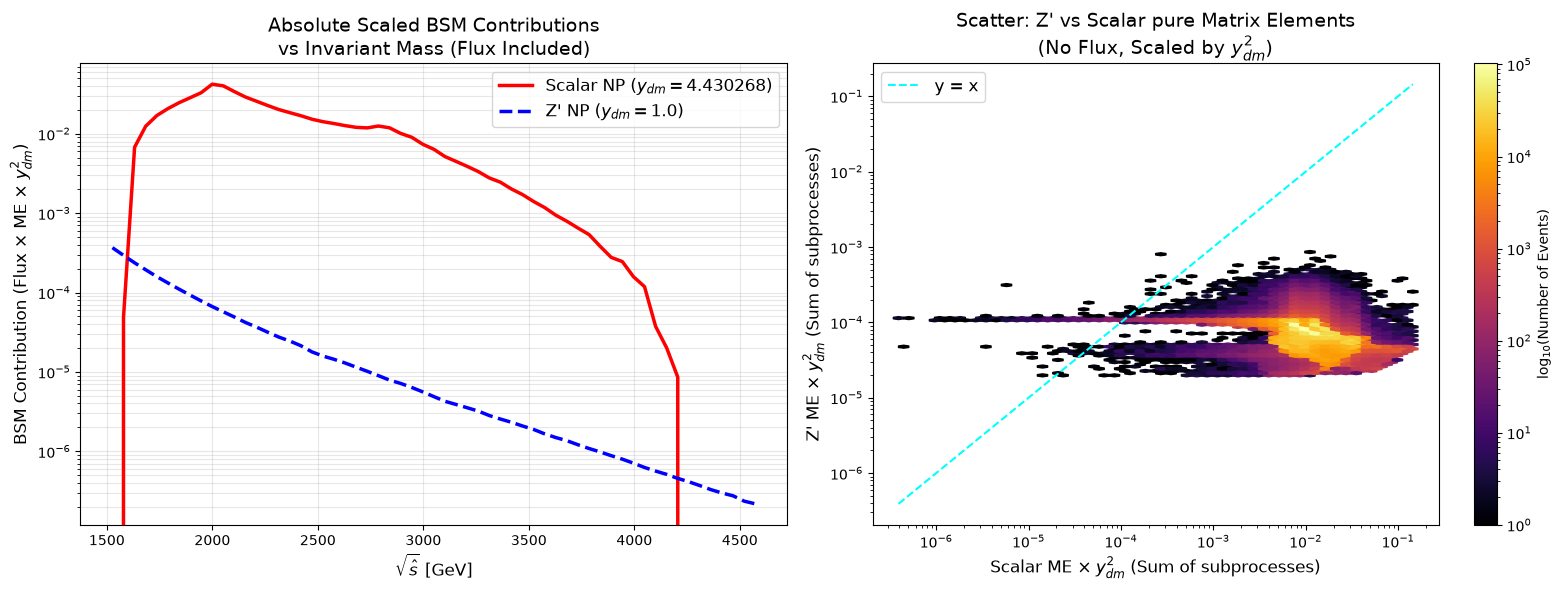

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["w_uux"] * df["ME_Born_NP_Zprime_P3_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_NP_Zprime_P5_ddx_ttx"]) +
    (df["w_gg"]  * df["ME_Born_NP_Zprime_P7_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P3_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P5_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P7_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Z' NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_Zprime_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_Zprime_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_Zprime_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_Zprime_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: Z' vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("Z' ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155536 events.
Computing and plotting...


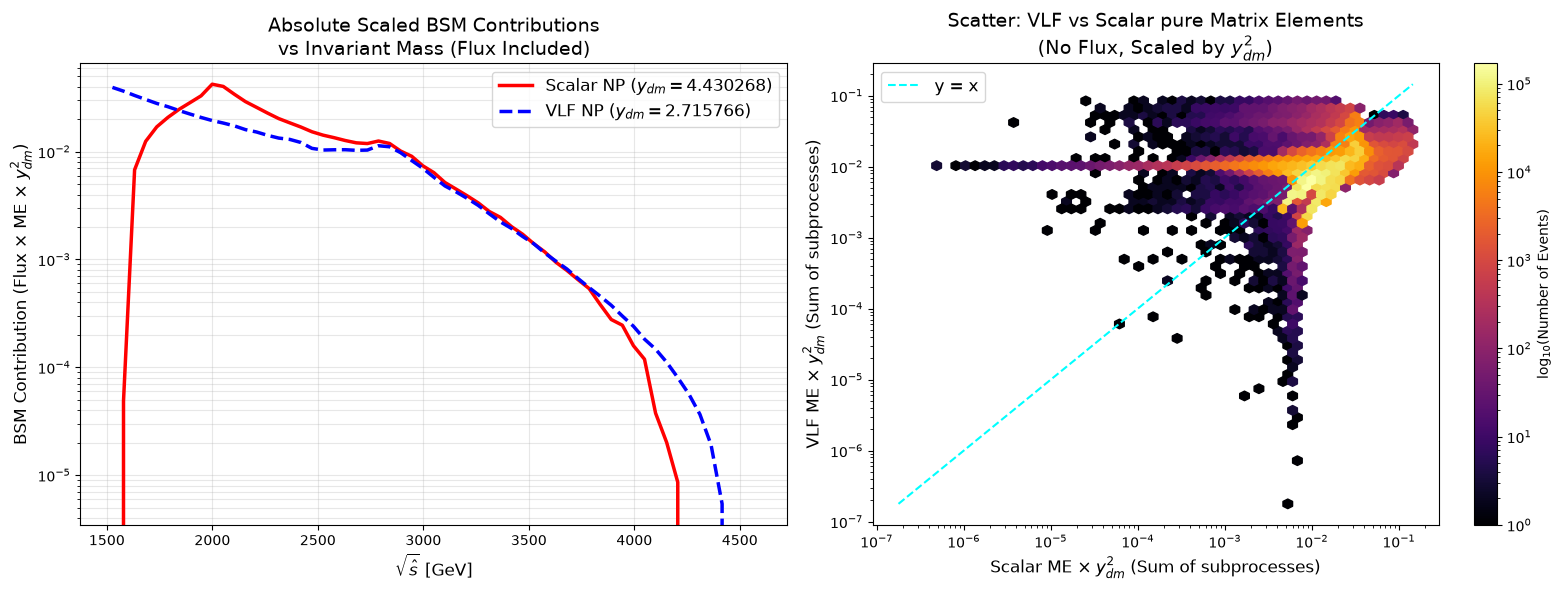

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + 
    df["ME_Finite_VLF_P2_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

In [31]:
import scipy.optimize as opt
# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 140.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Scale weights by the luminosity ---
# The weights now sum to the total expected events (N_events) instead of 1
df["scaled_weight"] = (df["mg_weight"] / df["mg_weight"].sum()) * N_events

# --- 3. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Calculate the expected LLR using the pre-computed normalized LLR
    weighted_llr = df["scaled_weight"] * df[f"LLR_Norm_{model}"]
    
    # Sum them up to get the total Joint LLR for this luminosity
    total_llr = weighted_llr.sum()
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance
    # The LLR will be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it's exactly 0 due to being the baseline itself)
        significance = 0.0
    
    print(f"Model: {model}")
    print(f"  -> Total Log-Likelihood Ratio: {total_llr:.2f}")
    print(f"  -> Asimov Significance       : {significance:.2f} sigma")


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 140.0 fb^-1
Expected Events : 393764.1
------------------------------------------------------------
Model: VLF
  -> Total Log-Likelihood Ratio: -858.56
  -> Asimov Significance       : 41.44 sigma
Model: Scalar
  -> Total Log-Likelihood Ratio: 0.00
  -> Asimov Significance       : 0.00 sigma
Model: Zprime
  -> Total Log-Likelihood Ratio: -1601.28
  -> Asimov Significance       : 56.59 sigma


In [34]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 140.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 140.0 fb^-1
Expected Events : 176576.3
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -1.496146e-03
  -> Total Log-Likelihood    : -264.18
  -> Asimov Significance     : 22.99 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -2.786289e-03
  -> Total Log-Likelihood    : -491.99
  -> Asimov Significance     : 31.37 sigma
------------------------------------------------------------


In [38]:
# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (NATIVE DATASET)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Scale native weights by the luminosity ---
# Because the dataset IS the Scalar model, we just scale the native weights
df["scaled_weight"] = (df["mg_weight"] / df["mg_weight"].sum()) * N_events

# --- 3. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Extract the pre-computed Log-Likelihood Ratio
    llr_raw = df[f"LLR_Norm_{model}"]
    
    # OUTLIER PROTECTION:
    # We clip the LLR to prevent single phase-space singularities from exploding.
    # A maximum Likelihood Ratio of 10,000 means a max LLR of ln(10000) ≈ 9.21.
    MAX_LLR_CAP = np.log(10000.0)
    MIN_LLR_CAP = np.log(1e-300) # Floor to prevent log(0) -inf math crashes
    
    llr_clipped = np.clip(llr_raw, a_min=MIN_LLR_CAP, a_max=MAX_LLR_CAP)
    
    # Calculate the weighted LLR
    weighted_llr = df["scaled_weight"] * llr_clipped
    
    # Sum them up to get the total Joint LLR for this luminosity
    total_llr = weighted_llr.sum()
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        significance = 0.0
        
    print(f"Model: {model}")
    print(f"  -> Max LLR (Before Clip)     : {llr_raw.max():.2f}")
    print(f"  -> Total Log-Likelihood Ratio: {total_llr:.2f}")
    print(f"  -> Asimov Significance       : {significance:.2f} sigma")


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (NATIVE DATASET)
Luminosity      : 500.0 fb^-1
Expected Events : 1406300.4
------------------------------------------------------------
Model: VLF
  -> Max LLR (Before Clip)     : 0.91
  -> Total Log-Likelihood Ratio: 359.76
  -> Asimov Significance       : 0.00 sigma
Model: Scalar
  -> Max LLR (Before Clip)     : 0.00
  -> Total Log-Likelihood Ratio: 0.00
  -> Asimov Significance       : 0.00 sigma
Model: Zprime
  -> Max LLR (Before Clip)     : 25.98
  -> Total Log-Likelihood Ratio: 12312442.11
  -> Asimov Significance       : 0.00 sigma


In [36]:
print(np.sqrt(11.013664))

3.3186840765580565


In [6]:
import pandas as pd
import numpy as np

# Load your existing dataframe
df = pd.read_csv("/home/vinicius/UnfoldingBSMttbar/Likelihoods_AllModels.csv.gz")

# Extract the raw Matrix Elements you already saved for the Scalar model
p_sm = df["P_SM_Scalar"]
p_bsm = df["P_BSM_Leading_Scalar"]

# ---------------------------------------------------------
# 1. THE ORIGINAL GENERATION (y_dm = 1.0)
# ---------------------------------------------------------
gen_y_dm = 1.0
p_gen = p_sm + ((gen_y_dm**2) * p_bsm)

# The sum of original MadGraph weights
sigma_orig = df["mg_weight"].sum()

print("=== CLOSURE TEST ===")
print(f"Original MadGraph Cross-Section (y_dm = {gen_y_dm}): {sigma_orig:.4f} pb")

# ---------------------------------------------------------
# 2. THE REWEIGHTING TO TARGET (y_dm = 4.430268)
# ---------------------------------------------------------
target_y_dm = 4.430268
p_target = p_sm + ((target_y_dm**2) * p_bsm)

# The core MC reweighting math: W_new = W_orig * (P_new / P_gen)
reweight_factor = np.where(p_gen > 0, p_target / p_gen, 0.0)
new_weights = df["mg_weight"] * reweight_factor

# The sum of the new weights
sigma_new = new_weights.sum()

print(f"Reweighted Cross-Section    (y_dm = {target_y_dm}): {sigma_new:.4f} pb")

=== CLOSURE TEST ===
Original MadGraph Cross-Section (y_dm = 1.0): 2.8300 pb
Reweighted Cross-Section    (y_dm = 4.430268): 2.8336 pb


In [5]:
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p



# ==========================================
# 4. MAIN LIKELIHOOD COMPUTATION LOOP
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path=None):
    print(f"Processing LHE file: {lhe_path}")
    print(f"Initializing LHAPDF with set {PDF_NAME}...")
    
    # --- THE FIX: Separate integer ID loading from string name loading ---
    if isinstance(PDF_NAME, int):
        pdf = lhapdf.mkPDF(PDF_NAME)
    else:
        pdf = lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except Exception:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    results = []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Computing MEM Likelihoods")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2:
            continue
            
        # Ensure strict ordering: [Top (6), Anti-Top (-6)]
        outgoing = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = outgoing[0], outgoing[1]
        
        # --- Kinematic Reconstruction ---
        # --- Kinematic Reconstruction ---
        E_tt  = t.e + tbar.e
        pz_tt = t.pz + tbar.pz
        x1 = (E_tt + pz_tt) / (2.0 * E_BEAM)
        x2 = (E_tt - pz_tt) / (2.0 * E_BEAM)
        
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0):
            continue
            
        px_tt = t.px + tbar.px
        py_tt = t.py + tbar.py
        s_hat = E_tt**2 - px_tt**2 - py_tt**2 - pz_tt**2
        
        # --- THE FIX: Assign independent scales ---
        alphas = pdf.alphasQ(MU_R)  # Strong coupling evaluated at the renormalization scale
        
        # Pre-compute Gluon PDF weight at the FACTORIZATION scale (MU_F)
        w_gg = (pdf.xfxQ(21, x1, MU_F) / x1) * (pdf.xfxQ(21, x2, MU_F) / x2)
        
        # Format 4-momenta aligned on z-axis for MadGraph evaluation
        p1 = [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM]
        p2 = [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM]
        p_list = [p1, p2, [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]]
        P_fortran = np.asfortranarray(invert_momenta(p_list), dtype=np.float64)
        
        # --- Model Hypothesis Likelihood Evaluation ---
        event_record = {
            "Event": idx,
            "x1": x1,
            "x2": x2,
            "s_hat": s_hat,
            "alphas": alphas,
            "w_gg": w_gg
        }
        
        try:
            # Loop dynamically over VLF, Scalar, and Zprime models
            for model_name, channels in models.items():
                likelihood_total = 0.0
                
                for ch_name, mod_data in channels.items():
                    # Pass MU_R2 (Renormalization scale squared) into Fortran!
                    me_val = eval_full_me(mod_data, P_fortran, alphas, MU_R2, -1)
                    
                    if "gg" in ch_name:
                        likelihood_total += w_gg * me_val
                    else:
                        q_str = next((k for k in PDG_MAP.keys() if k in ch_name), "uux")
                        q_id = PDG_MAP[q_str]
                        
                        # Compute flavor-specific PDF weight at the FACTORIZATION scale (MU_F)
                        fq_1    = pdf.xfxQ(q_id, x1, MU_F) / x1
                        fqbar_2 = pdf.xfxQ(-q_id, x2, MU_F) / x2
                        fqbar_1 = pdf.xfxQ(-q_id, x1, MU_F) / x1
                        fq_2    = pdf.xfxQ(q_id, x2, MU_F) / x2
                        
                        w_qq_flavor = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
                        likelihood_total += w_qq_flavor * me_val
                
                event_record[f"L_{model_name}"] = likelihood_total
                
            results.append(event_record)
            
        except Exception as e:
            tqdm.write(f"Error computing ME for event {idx}: {e}")
            continue

    df = pd.DataFrame(results).dropna().reset_index(drop=True)
    print(f"\nSuccessfully computed MEM likelihoods for {len(df)} events.")
    
    # Save directly to disk if an output path is provided
    if output_csv_path:
        df.to_csv(output_csv_path, index=False, compression='infer')
        print(f"Saved likelihood dataframe to: {output_csv_path}")
        
    return df

# --- Execution Example ---
lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/no_cuts_1000_900/events.lhe.gz"
output_file   = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"

df_mem = compute_matrix_elements(lhe_file_path, output_csv_path=output_file)
print(df_mem.head())

Processing LHE file: /home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/no_cuts_1000_900/events.lhe.gz
Initializing LHAPDF with set 244600...
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600


Computing MEM Likelihoods:   0%|       | 47/1512458 [00:00<1:45:40, 238.53it/s]

 {                                                                                          }
 {                                                                                          }
 {                                      ,,                                                  }
 {       `7MMM.     ,MMF'             `7MM  `7MMF'                                          }
 {         MMMb    dPMM                 MM    MM                                            }
 {         M YM   ,M MM   ,6"Yb.   ,M""bMM    MM         ,pW"Wq.   ,pW"Wq.`7MMpdMAo.        }
 {         M  Mb  M' MM  8)   MM ,AP    MM    MM        6W'   `Wb 6W'   `Wb MM   `Wb        }
 {         M  YM.P'  MM   ,pm9MM 8MI    MM    MM      , 8M     M8 8M     M8 MM    M8        }
 {         M  `YM'   MM  8M   MM `Mb    MM    MM     ,M YA.   ,A9 YA.   ,A9 MM   ,AP        }
 {       .JML. `'  .JMML.`Moo9^Yo.`Wbmd"MML..JMMmmmmMMM  `Ybmd9'   `Ybmd9'  MMbmmd'         }
 {                                                          

Computing MEM Likelihoods:   0%|        | 167/1512458 [00:00<53:54, 467.54it/s]

#############################

  +----------------------------------------------------------------+
  |                                                                |
  |  Ninja - version 1.2.0                                         |
  |                                                                |
  |  Author: Tiziano Peraro                                        |
  |                                                                |
  |  Based on:                                                     |
  |                                                                |
  |      P. Mastrolia, E. Mirabella and T. Peraro,                 |
  |      "Integrand reduction of one-loop scattering amplitudes    |
  |      through Laurent series expansion,"                        |
  |      JHEP 1206 (2012) 095  [arXiv:1203.0291 [hep-ph]].         |
  |                                                                |
  |      T. Peraro,                                                |
  |

...

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


Computing MEM Likelihoods:   2%|      | 23757/1512458 [00:39<44:26, 558.38it/s]

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


Computing MEM Likelihoods: 100%|████| 1512458/1512458 [47:06<00:00, 535.10it/s]



Successfully computed MEM likelihoods for 1512458 events.
Saved likelihood dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
   Event        x1        x2          s_hat    alphas          w_gg  \
0      0  0.003283  0.301707  167396.028053  0.118002   1363.984763   
1      1  0.011102  0.090365  169545.752140  0.118002   8080.706123   
2      2  0.008465  0.099426  142233.763263  0.118002  10032.033844   
3      3  0.009182  0.093485  145058.338567  0.118002  10199.997512   
4      4  0.012233  0.074237  153470.806376  0.118002  10900.279100   

         L_VLF     L_Scalar     L_Zprime  
0  1320.908694  1319.570231  1453.557094  
1  6908.645384  6900.641350  7259.983018  
2  5877.781541  5870.308192  6320.420915  
3  6125.311667  6117.664906  6561.004892  
4  7579.018238  7569.640558  8008.722968  


Loading dataset from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
Total events: 1,512,458
Valid positive phase-space events: 1,512,143 (Dropped 315 unphysical/negative rows)

--- Summary of Test Statistics ---
       LLR_VLF_vs_Scalar  LLR_Zprime_vs_Scalar
count       1.512143e+06          1.512143e+06
mean        9.068212e-04          6.296907e-02
std         3.839962e-03          3.514216e-02
min        -3.254986e+00         -4.633553e-01
25%         9.053614e-04          4.150271e-02
50%         9.884168e-04          5.802949e-02
75%         1.091286e-03          7.576623e-02
max         4.032598e-02          4.611974e+00

Saved updated LLR dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz
Saved LLR distribution plot to: /home/vinicius/UnfoldingBSMttbar/Hypothesis_Test_LLR_Distributions.png


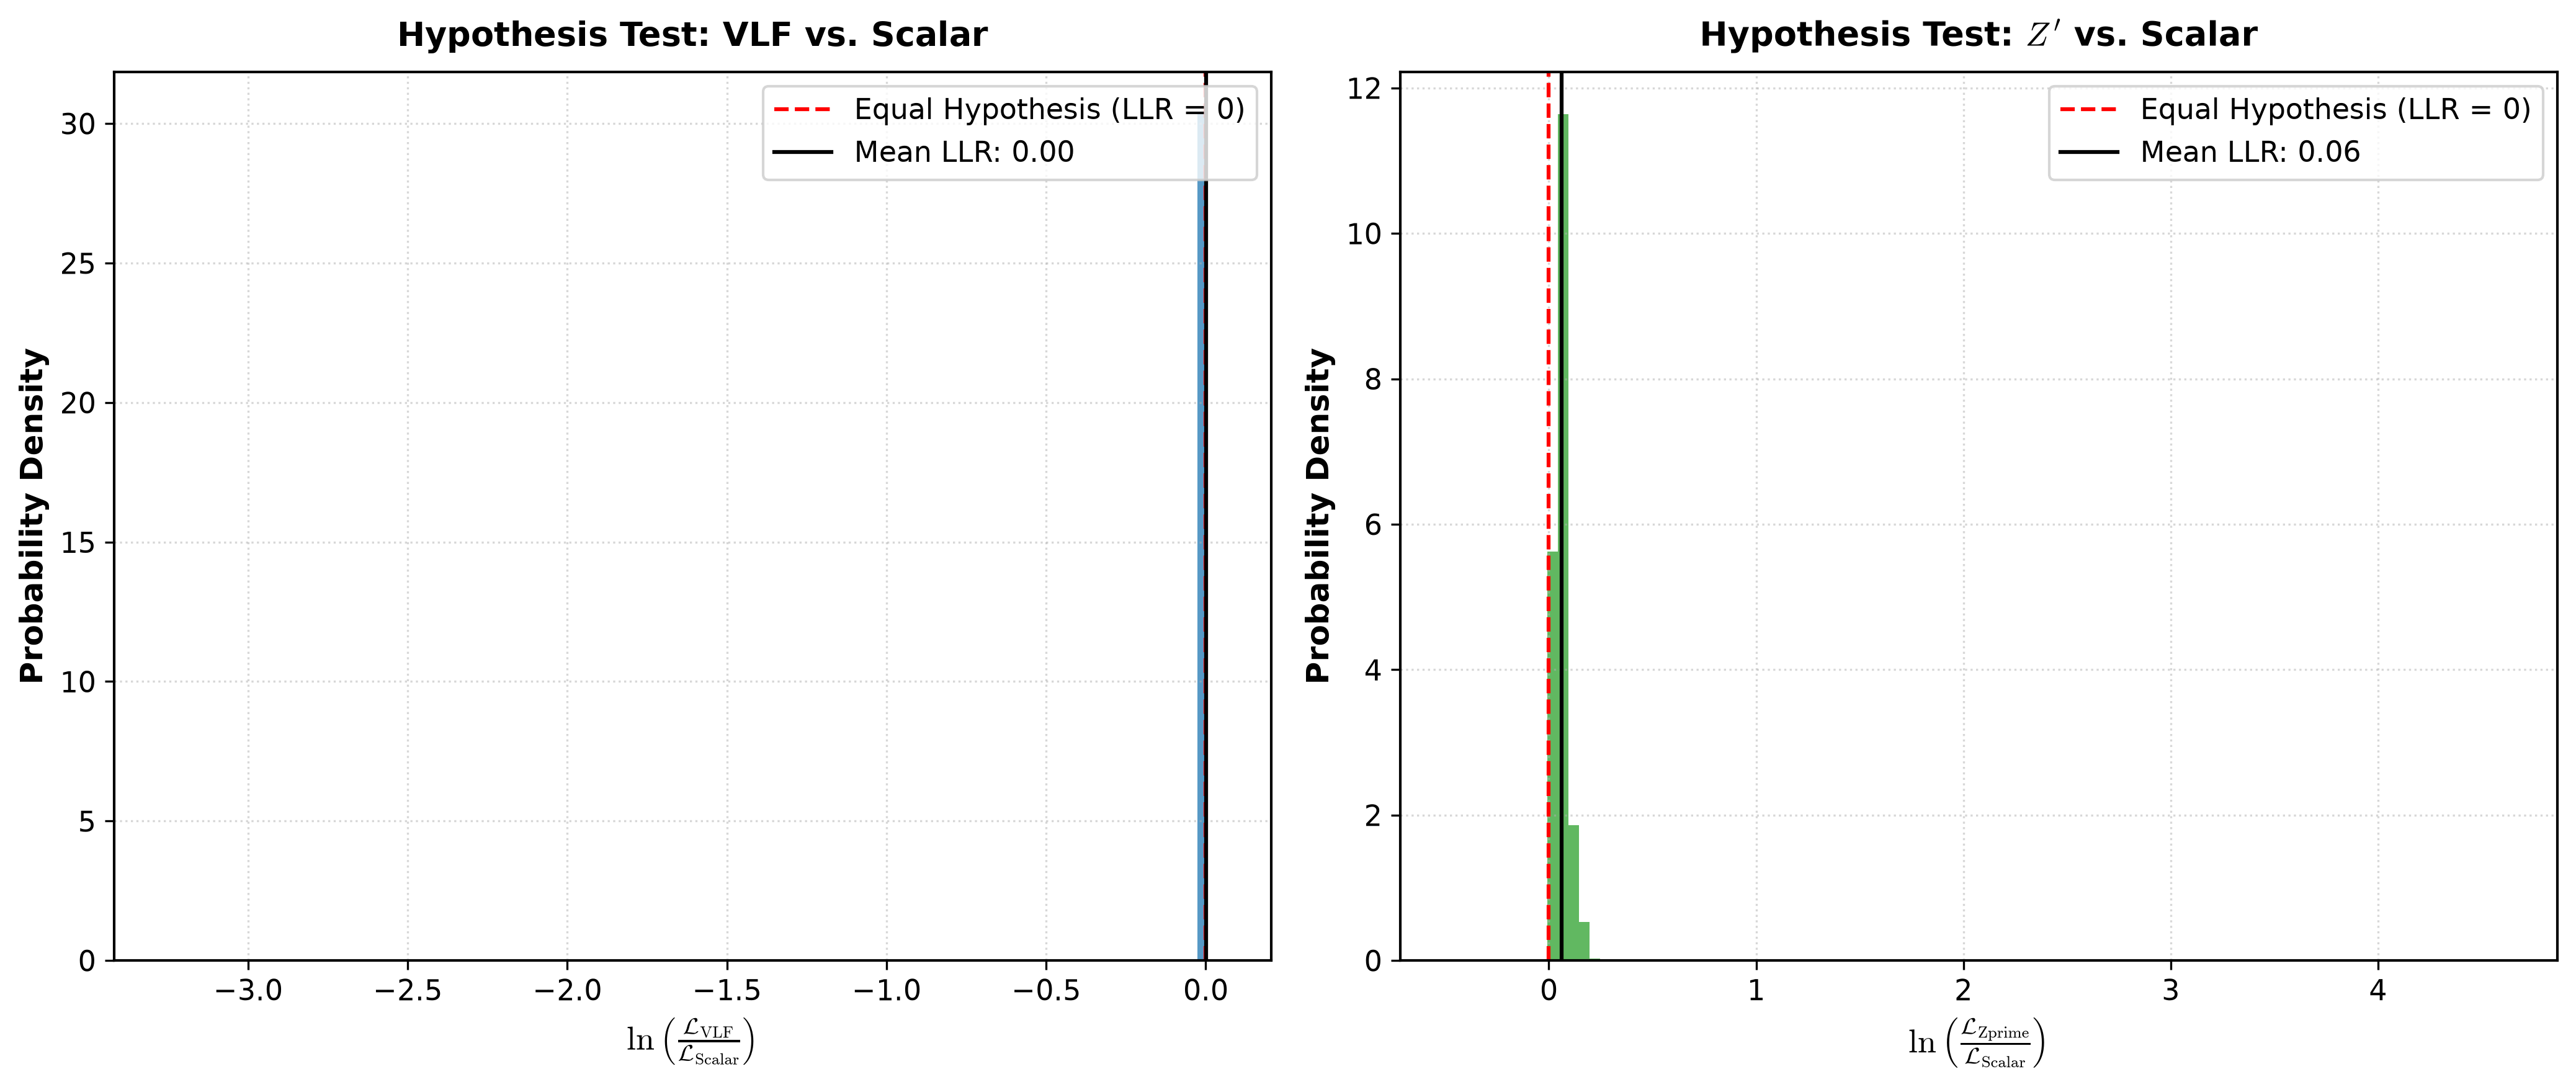

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD THE DATA
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# ==========================================
# 2. DATA CLEANING & POSITIVITY FILTER
# ==========================================
# Logarithms are undefined for L <= 0. In 1-loop calculations, local NLO interference
# can produce small negative weights. We filter to retain only strictly positive, physical phase space.
initial_count = len(df)
valid_mask = (df['L_Scalar'] > 0) & (df['L_VLF'] > 0) & (df['L_Zprime'] > 0)
df_clean = df[valid_mask].copy()

dropped_count = initial_count - len(df_clean)
print(f"Total events: {initial_count:,}")
print(f"Valid positive phase-space events: {len(df_clean):,} (Dropped {dropped_count:,} unphysical/negative rows)")

# ==========================================
# 3. COMPUTE LOG-LIKELIHOOD RATIOS (LLR)
# ==========================================
# Using ln(A/B) = ln(A) - ln(B) for numerical precision
df_clean['logL_Scalar'] = np.log(df_clean['L_Scalar'])
df_clean['logL_VLF']    = np.log(df_clean['L_VLF'])
df_clean['logL_Zprime'] = np.log(df_clean['L_Zprime'])

# Test Statistics: Testing Models against the Scalar hypothesis
df_clean['LLR_VLF_vs_Scalar']    = df_clean['logL_VLF'] - df_clean['logL_Scalar']
df_clean['LLR_Zprime_vs_Scalar'] = df_clean['logL_Zprime'] - df_clean['logL_Scalar']

# Display summary statistics of the test statistics
print("\n--- Summary of Test Statistics ---")
print(df_clean[['LLR_VLF_vs_Scalar', 'LLR_Zprime_vs_Scalar']].describe())

# Save the updated dataframe with LLR columns for downstream analysis
output_csv = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz"
df_clean.to_csv(output_csv, index=False, compression='infer')
print(f"\nSaved updated LLR dataframe to: {output_csv}")

# ==========================================
# 4. VISUALIZE THE LLR DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# --- Plot 1: VLF vs Scalar ---
ax1 = axes[0]
ax1.hist(df_clean['LLR_VLF_vs_Scalar'], bins=100, color='#1f77b4', alpha=0.75, density=True, edgecolor='none')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Hypothesis (LLR = 0)')
ax1.axvline(df_clean['LLR_VLF_vs_Scalar'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean LLR: {df_clean['LLR_VLF_vs_Scalar'].mean():.2f}")
ax1.set_xlabel(r'$\ln\left(\frac{\mathcal{L}_{\text{VLF}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title('Hypothesis Test: VLF vs. Scalar', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

# --- Plot 2: Zprime vs Scalar ---
ax2 = axes[1]
ax2.hist(df_clean['LLR_Zprime_vs_Scalar'], bins=100, color='#2ca02c', alpha=0.75, density=True, edgecolor='none')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Hypothesis (LLR = 0)')
ax2.axvline(df_clean['LLR_Zprime_vs_Scalar'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean LLR: {df_clean['LLR_Zprime_vs_Scalar'].mean():.2f}")
ax2.set_xlabel(r'$\ln\left(\frac{\mathcal{L}_{\text{Zprime}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=13, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Hypothesis Test: $Z^\prime$ vs. Scalar', fontsize=13, fontweight='bold', pad=10)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plot_path = "/home/vinicius/UnfoldingBSMttbar/Hypothesis_Test_LLR_Distributions.png"
plt.savefig(plot_path, dpi=300)
print(f"Saved LLR distribution plot to: {plot_path}")

plt.show()

Loading dataset from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz

--- Asymptotic Analytical Estimate (for N_exp = 1936 events) ---
Expected per-event LLR mean: 0.0009 | std: 0.0038
Expected joint LLR mean:     1.76 | std: 0.17
Estimated Significance:      10.39 sigma

Running 10,000 Toy MC experiments sampling 1936 events each...
Toy MC p-value:          4.869000e-01
Toy MC Significance (Z): 0.03 sigma

Saved significance separation plot to: /home/vinicius/UnfoldingBSMttbar/MEM_Significance_ToyMC.png


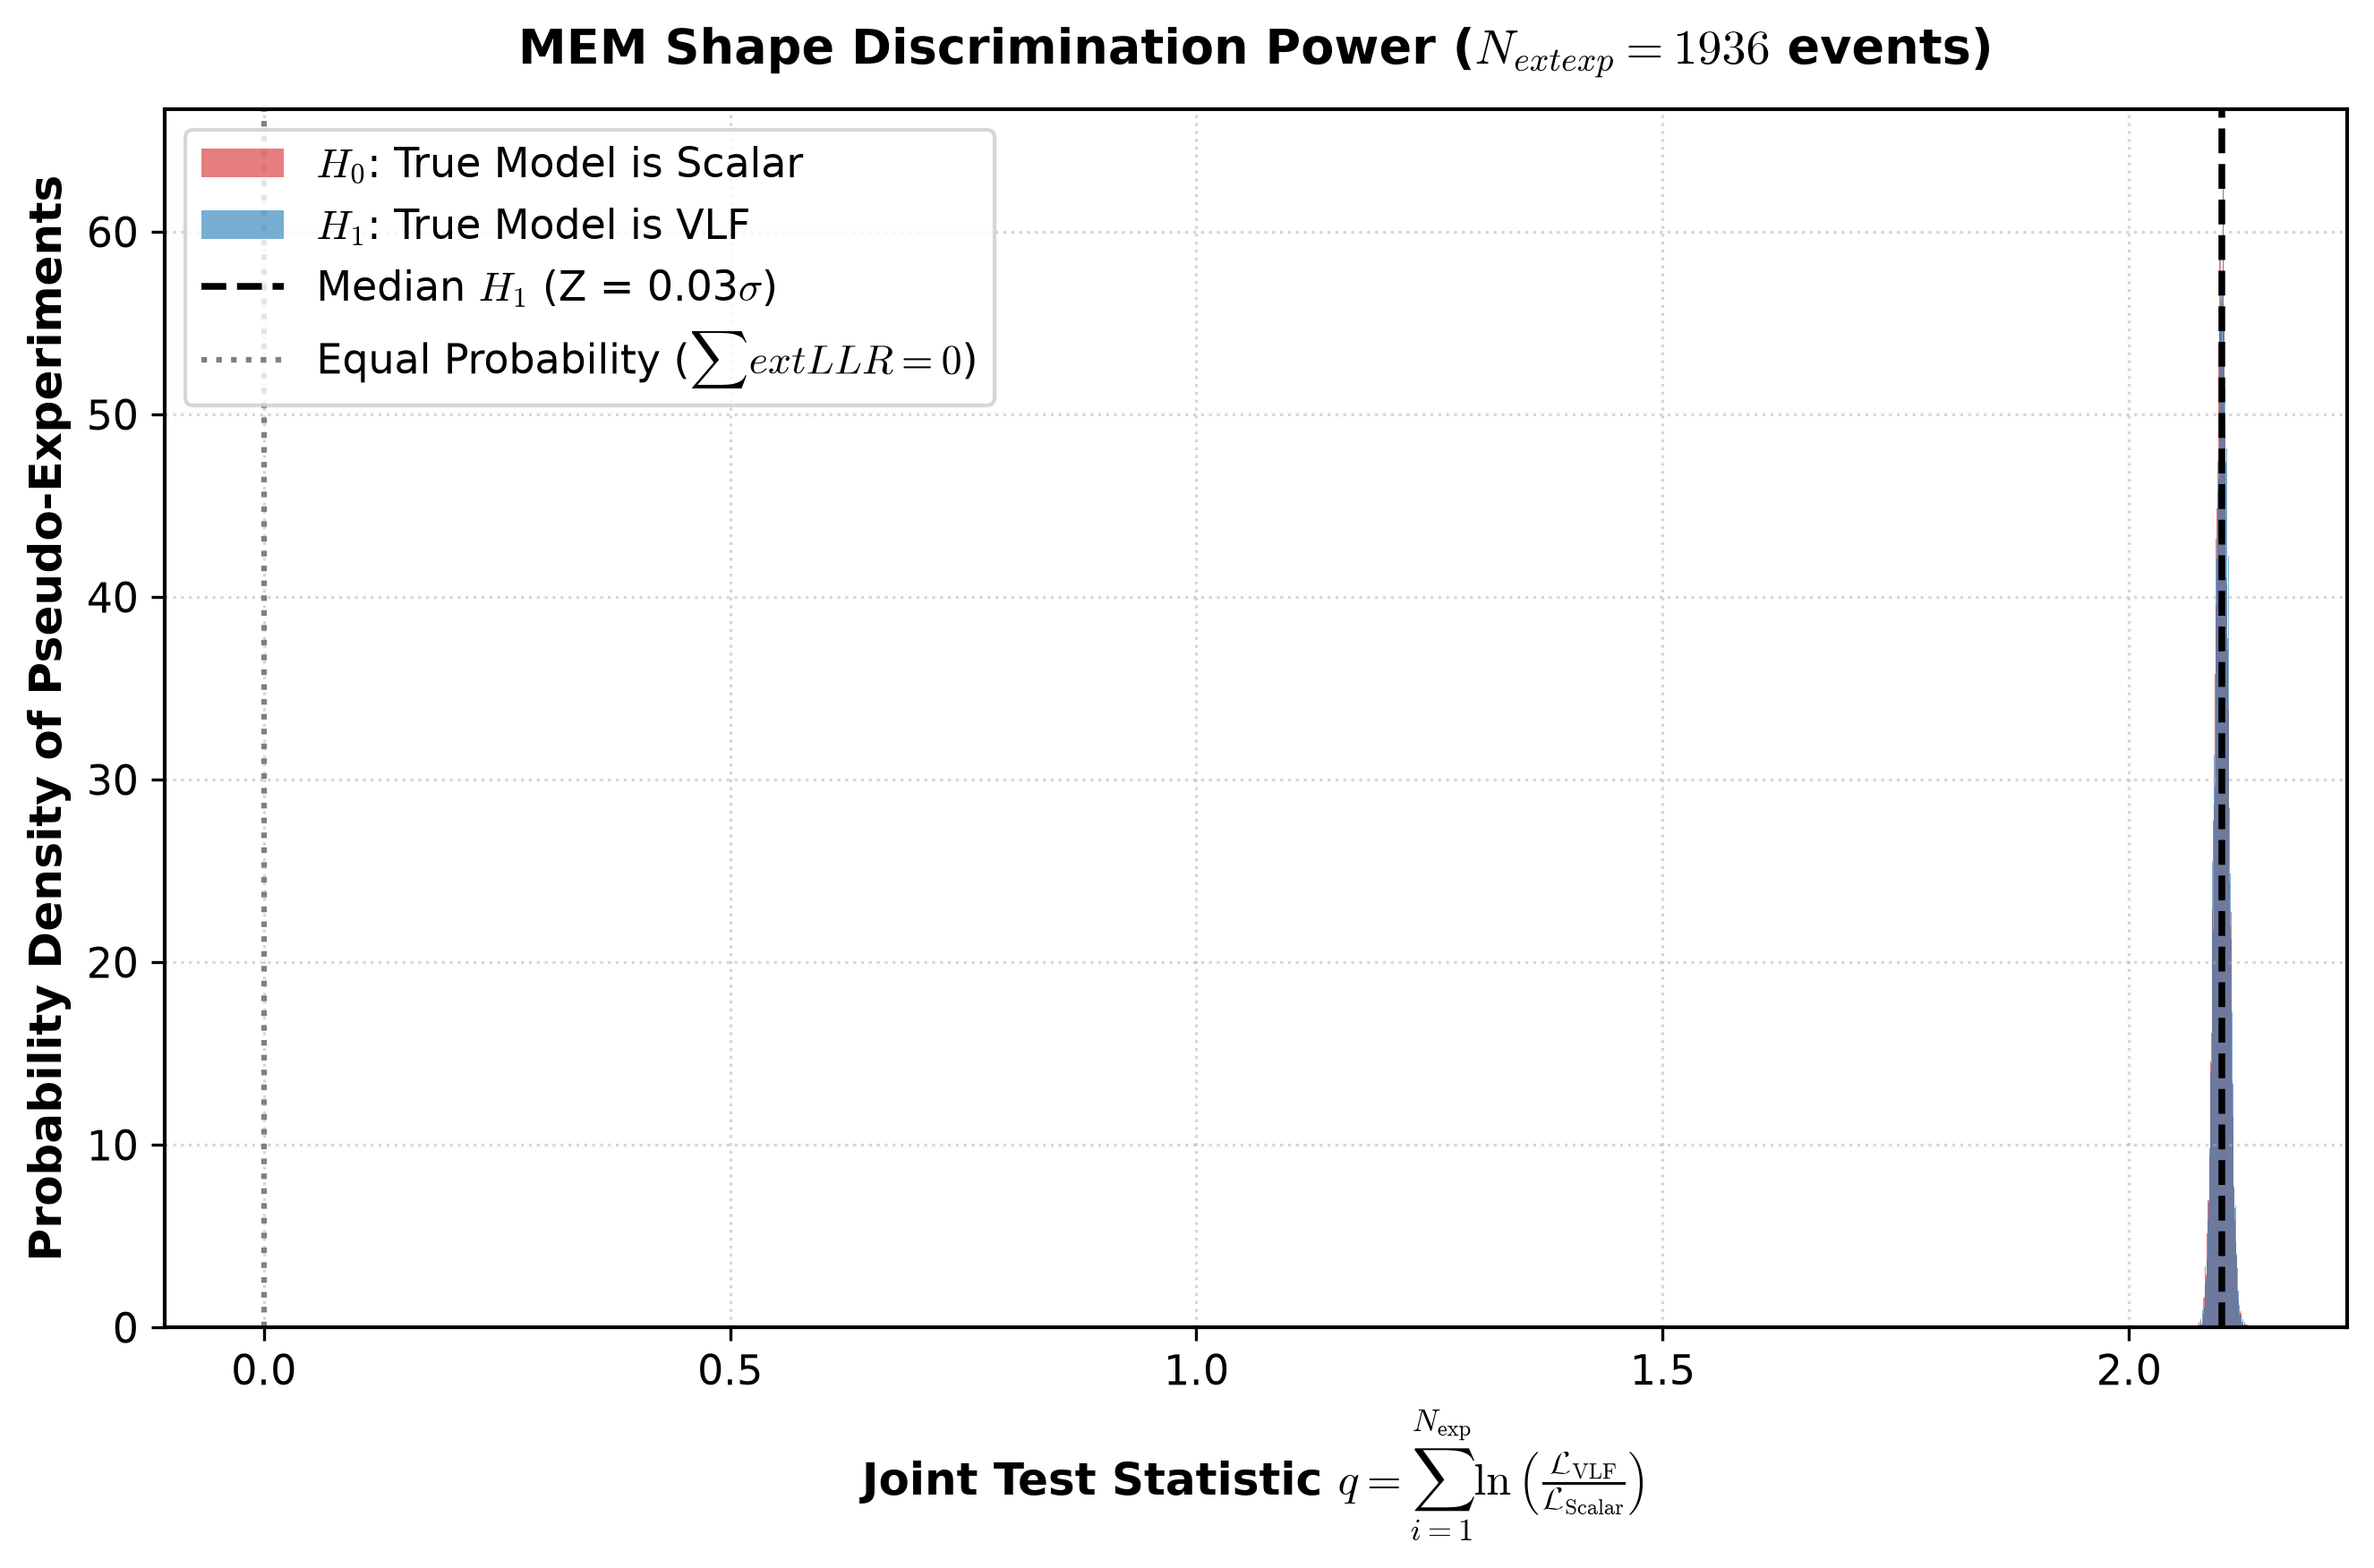

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. LOAD DATA & CONFIGURATION
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# --- EXPERIMENTAL PARAMETERS ---
# Set how many signal events you expect to observe in a real LHC run
# e.g., N_exp = 500 events after cuts for a given integrated luminosity
N_EXP = 1936         # Expected observed events per experiment
N_TOYS = 10000      # Number of pseudo-experiments to simulate

# We test VLF against Scalar using our pre-computed column
llr_col = 'LLR_VLF_vs_Scalar'
llr_data = df[llr_col].values

# ==========================================
# 2. ASYMPTOTIC ESTIMATE (CLT)
# ==========================================
# When Scalar is true (H0), the LLR tends to be negative.
# When VLF is true (H1), the LLR tends to be positive.
mu_per_event = np.mean(llr_data)
std_per_event = np.std(llr_data)

# By the Central Limit Theorem, for N_EXP events:
mu_total = N_EXP * mu_per_event
std_total = np.sqrt(N_EXP) * std_per_event

# Asymptotic significance estimate testing against LLR = 0
z_asymptotic = np.abs(mu_total) / std_total
print(f"\n--- Asymptotic Analytical Estimate (for N_exp = {N_EXP} events) ---")
print(f"Expected per-event LLR mean: {mu_per_event:.4f} | std: {std_per_event:.4f}")
print(f"Expected joint LLR mean:     {mu_total:.2f} | std: {std_total:.2f}")
print(f"Estimated Significance:      {z_asymptotic:.2f} sigma")

# ==========================================
# 3. TOY MONTE CARLO PSEUDO-EXPERIMENTS
# ==========================================
print(f"\nRunning {N_TOYS:,} Toy MC experiments sampling {N_EXP} events each...")

# To rigorously simulate H0 (Scalar true) vs H1 (VLF true) from a single kinematic pool,
# we reweight the sampling probabilities by the model likelihoods.
# Probability of pulling an event if Scalar is true is proportional to L_Scalar:
p_scalar = df['L_Scalar'].values / np.sum(df['L_Scalar'].values)

# Probability of pulling an event if VLF is true is proportional to L_VLF:
p_vlf = df['L_VLF'].values / np.sum(df['L_VLF'].values)

# Generate pseudo-experiments using fast NumPy vectorized matrix sampling
# Shape: (N_TOYS, N_EXP) -> sum along axis 1 gives total LLR per toy experiment
toys_H0  = np.random.choice(llr_data, size=(N_TOYS, N_EXP), p=p_scalar).sum(axis=1)
toys_H1    = np.random.choice(llr_data, size=(N_TOYS, N_EXP), p=p_vlf).sum(axis=1)

# ==========================================
# 4. COMPUTE EXACT P-VALUE AND SIGNIFICANCE
# ==========================================
# The median sensitivity of H1 testing against the H0 distribution
median_H1 = np.median(toys_H1)
p_value = np.mean(toys_H0 >= median_H1)  # Fraction of H0 toys leaking past H1 median

# Handle numerical limits if separation is total (p_value == 0)
if p_value == 0:
    p_value = 1.0 / N_TOYS
    print(f"\nExact p-value is smaller than 1/{N_TOYS}. Separation is extremely strong!")
    
z_toy = norm.ppf(1.0 - p_value)
print(f"Toy MC p-value:          {p_value:.6e}")
print(f"Toy MC Significance (Z): {z_toy:.2f} sigma")

# ==========================================
# 5. PLOT STATISTICAL SEPARATION CURVES
# ==========================================
plt.figure(figsize=(9, 6), dpi=300)

# Plot Null Hypothesis (Scalar)
plt.hist(toys_H0, bins=80, color='#d62728', alpha=0.6, density=True, label=r'$H_0$: True Model is Scalar')

# Plot Alternative Hypothesis (VLF)
plt.hist(toys_H1, bins=80, color='#1f77b4', alpha=0.6, density=True, label=r'$H_1$: True Model is VLF')

# Draw Median Reference Line
plt.axvline(median_H1, color='black', linestyle='--', linewidth=1.8, label=f'Median $H_1$ (Z = {z_toy:.2f}$\sigma$)')
plt.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Equal Probability ($\sum \text{LLR} = 0$)')

plt.xlabel(r'Joint Test Statistic $q = \sum_{i=1}^{N_{\text{exp}}} \ln\left(\frac{\mathcal{L}_{\text{VLF}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density of Pseudo-Experiments', fontsize=12, fontweight='bold')
plt.title(f'MEM Shape Discrimination Power ($N_{{\text{{exp}}}} = {N_EXP}$ events)', fontsize=13, fontweight='bold', pad=12)

plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

output_plot = "/home/vinicius/UnfoldingBSMttbar/MEM_Significance_ToyMC.png"
plt.tight_layout()
plt.savefig(output_plot, dpi=300)
print(f"\nSaved significance separation plot to: {output_plot}")

plt.show()

In [5]:

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p
# ==========================================
# 4. RANDOM 2->2 KINEMATIC PHASE SPACE GENERATOR
# ==========================================
def generate_random_ttbar_momenta(e_beam, m_top=172.5, seed=None):
    """
    Generates a valid, energy-momentum conserved 4-momentum array [E, px, py, pz]
    for a 2 -> 2 collision: ab -> t + tbar.
    """
    if seed is not None:
        np.random.seed(seed)
        
    # 1. Sample random parton momentum fractions x1, x2 above the ttbar threshold
    s_tot = (2.0 * e_beam)**2
    tau_min = (2.0 * m_top)**2 / s_tot
    
    # Sample x1 exponentially/uniformly and derive x2 above threshold
    x1 = np.random.uniform(np.sqrt(tau_min), 0.8)
    x2 = np.random.uniform(tau_min / x1, 0.8)
    
    s_hat = x1 * x2 * s_tot
    e_cm = np.sqrt(s_hat)
    
    # 2. Define incoming parton 4-momenta in the lab frame [E, px, py, pz]
    p1 = [x1 * e_beam, 0.0, 0.0,  x1 * e_beam]
    p2 = [x2 * e_beam, 0.0, 0.0, -x2 * e_beam]
    
    # 3. Generate top quark momenta in the center-of-mass (CM) frame
    p_mag_cm = np.sqrt((e_cm / 2.0)**2 - m_top**2)
    
    cos_theta = np.random.uniform(-0.9, 0.9)
    sin_theta = np.sqrt(1.0 - cos_theta**2)
    phi = np.random.uniform(0.0, 2.0 * np.pi)
    
    p3_cm = [
        e_cm / 2.0,
        p_mag_cm * sin_theta * np.cos(phi),
        p_mag_cm * sin_theta * np.sin(phi),
        p_mag_cm * cos_theta
    ]
    p4_cm = [
        e_cm / 2.0,
        -p3_cm[1],
        -p3_cm[2],
        -p3_cm[3]
    ]
    
    # 4. Boost outgoing top quarks along z-axis back to the laboratory frame
    beta_z = (x1 - x2) / (x1 + x2)
    gamma = 1.0 / np.sqrt(1.0 - beta_z**2)
    
    def boost_z(p_4vec):
        e, px, py, pz = p_4vec
        return [
            gamma * (e + beta_z * pz),
            px,
            py,
            gamma * (pz + beta_z * e)
        ]
        
    p3 = boost_z(p3_cm)
    p4 = boost_z(p4_cm)
    
    return [p1, p2, p3, p4], {
        "x1": x1, "x2": x2, 
        "s_hat": s_hat, "sqrt_s_hat": e_cm,
        "cos_theta_cm": cos_theta
    }

# ==========================================
# 5. SANITY CHECK: EVALUATE ALL MODELS
# ==========================================
print("Running Sanity Check: Matrix Element Evaluation...\n" + "="*65)

# 1. Initialize LHAPDF to get physical alpha_s at MU_R
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
    print(f"LHAPDF initialized successfully: PDF ID = {PDF_NAME}")
except Exception as e:
    # Fallback to the physical constant if LHAPDF data files are missing locally
    alphas = 0.088464
    print(f"LHAPDF fallback: Using default alpha_s(mu_R={MU_R} GeV) = {alphas}")

print(f"Renormalization Scale mu_R = {MU_R} GeV | alpha_s = {alphas:.6f}")

# 2. Generate a single random kinematic collision point
p_lab, kin_info = generate_random_ttbar_momenta(E_BEAM, m_top=172.5, seed=101)
p_fortran = invert_momenta(p_lab)

print(f"\nRandom Kinematic Phase-Space Point Generated:")
print(f" -> x1 = {kin_info['x1']:.4f} | x2 = {kin_info['x2']:.4f}")
print(f" -> sqrt(s_hat) = {kin_info['sqrt_s_hat']:.2f} GeV | cos(theta*) = {kin_info['cos_theta_cm']:.3f}\n")

# 3. Loop over all registries and evaluate |M|^2
results = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            me_val = eval_full_me(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            me_val = np.nan
            status = f"FAILED: {str(err)[:30]}..."
            
        results.append({
            "Model": model_name,
            "Subprocess": channel_name,
            "|M|^2 (Raw Value)": f"{me_val:.6e}" if not np.isnan(me_val) else "NaN",
            "Status": status
        })

# ==========================================
# 6. DISPLAY COMPARISON TABLE
# ==========================================
df_sanity = pd.DataFrame(results)
print(df_sanity.to_string(index=False))
print("\n" + "="*65)
print("[✓] Sanity check complete. Check that all status flags read 'OK' and values are strictly non-NaN.")

Running Sanity Check: Matrix Element Evaluation...
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600
LHAPDF initialized successfully: PDF ID = 244600
Renormalization Scale mu_R = 91.188 GeV | alpha_s = 0.118002

Random Kinematic Phase-Space Point Generated:
 -> x1 = 0.4260 | x2 = 0.4572
 -> sqrt(s_hat) = 5737.18 GeV | cos(theta*) = -0.849



TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [55]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import lhapdf

# ==========================================
# 1. DEFINE YOUR SPECIFIC PHASE SPACE POINT
# ==========================================
# Format: [E, px, py, pz] in GeV
# Center-of-mass energy sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
p_user_lab = [
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00,  0.5000000E+03],
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00, -0.5000000E+03],
    [0.5000000E+03,  0.1041545E+03,  0.4176826E+03, -0.1873741E+03],
    [0.5000000E+03, -0.1041545E+03, -0.4176826E+03,  0.1873741E+03]
]

p_user_lab = [
    [0.5000000E+03,  0.0000000E+00,   0.0000000E+00,  0.5000000E+03],
    [0.5000000E+03,  0.0000000E+00,   0.0000000E+00, -0.5000000E+03],
    [0.5000000E+03, -0.1773983e-306, -0.1736952E+03, -0.4361720E+03],
    [0.5000000E+03,  0.1773983e-306,  0.1736952E+03,  0.4361720E+03]
]

# Transpose array to match Fortran memory layout (4 x N_particles)
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

p_fortran = invert_momenta(p_user_lab)

# ==========================================
# 2. DYNAMIC COMPONENT UNPACKER
# ==========================================
def eval_full_me_components(module_dict, p_fortran, alphas, scale2, nhel=-1):
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (get_value) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            born_val = val_list[0] if len(val_list) > 0 else 0.0
            
            return {
                "Type": "LO (Tree)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": 0.0,
                "Single Pole (1/eps)": 0.0,
                "Double Pole (1/eps^2)": 0.0,
                "MadLoop Code": "N/A",
                "Raw Array": val_list
            }
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (get_me) ---
        elif nlo_eval:
            res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            
            # Convert to a NumPy array to check its structural shape
            res_arr = np.array(res)
            
            # DYNAMIC CHECK: Keep the debug print so you can see the raw output structure
            print(f"Debug Raw Array Shape for {os.path.basename(subproc_path)}: {res_arr.shape}")
            
            if res_arr.ndim == 2:
                # [NEW] 2D Patched Wrapper with Split Orders
                
                # Safe Extraction Logic:
                if res_arr.shape[1] > 3:
                    # For P3/P5 (q q~): Array is wide. Extract specific columns.
                    # Column 3 = Pure SM QCD, Column 1 = Pure Z'
                    born_val = float(res_arr[0, 3])
                    finite_val = float(res_arr[0, 1])
                else:
                    # For P7 (gg): Array is narrow. Column 0 is the total sum (which is pure SM QCD)
                    born_val = float(res_arr[0, 0]) 
                    print(res_arr)
                    finite_val = 0
                
                
                pole1_val  = float(res_arr[2, 0])
                pole2_val  = float(res_arr[3, 0])
                
            elif res_arr.ndim == 1 and res_arr.size == 4:
                # 1D Patched Wrapper (Shape: 4)
                born_val   = float(res_arr[0])
                finite_val = float(res_arr[1])
                pole1_val  = float(res_arr[2])
                pole2_val  = float(res_arr[3])
                
            else:
                # Unpatched Original Wrapper (Returns only the Finite term)
                res_list = np.ravel(res_arr)
                born_val   = 0.0
                finite_val = float(res_list[0]) if len(res_list) > 0 else 0.0
                pole1_val  = float(res_list[1]) if len(res_list) > 1 else 0.0
                pole2_val  = float(res_list[2]) if len(res_list) > 2 else 0.0
            
            return {
                "Type": "NLO (MadLoop)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": finite_val,
                "Single Pole (1/eps)": pole1_val,
                "Double Pole (1/eps^2)": pole2_val,
                "MadLoop Code": str(int(ret_code)) if isinstance(ret_code, (int, float, np.number)) else str(ret_code),
                "Raw Array": np.ravel(res_arr).tolist()
            }
        else:
            raise AttributeError("Module defines neither get_value nor get_me!")
            
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. EVALUATE ALL MODELS FOR THIS EXACT POINT
# ==========================================
print("Evaluating Specific Phase Space Point Across Models...\n" + "="*85)
print(f"Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV")
print(f"Top-Quark Momentum: p3 = [{p_user_lab[2][0]:.1f}, {p_user_lab[2][1]:.2e}, {p_user_lab[2][2]:.1f}, {p_user_lab[2][3]:.1f}] GeV\n")

# Initialize LHAPDF to get physical alpha_s at MU_R = 1000 GeV
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
except Exception:
    alphas = 0.088464 # Physical fallback

results_detailed = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            comps = eval_full_me_components(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            comps = {
                "Type": "ERROR", "Born (|M0|^2)": np.nan, "Finite 1-Loop": np.nan,
                "Single Pole (1/eps)": np.nan, "Double Pole (1/eps^2)": np.nan,
                "MadLoop Code": "ERR", "Raw Array": []
            }
            status = f"FAIL: {str(err)[:20]}"
            
        results_detailed.append({
            "Model": model_name,
            "Channel": channel_name,
            "Type": comps["Type"],
            "Born (|M0|^2)": f"{comps['Born (|M0|^2)']:.4e}",
            "Finite 1-Loop": f"{comps['Finite 1-Loop']:.4e}",
            "Single Pole (1/eps)": f"{comps['Single Pole (1/eps)']:.4e}",
            "Double Pole (1/eps^2)": f"{comps['Double Pole (1/eps^2)']:.4e}",
            "MadLoop Code": comps["MadLoop Code"],
            "Status": status
        })

# ==========================================
# 4. DISPLAY FULL COMPONENT TABLE
# ==========================================
df_components = pd.DataFrame(results_detailed)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_components.to_string(index=False))
print("="*85)

Evaluating Specific Phase Space Point Across Models...
Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
Top-Quark Momentum: p3 = [500.0, -1.77e-307, -173.7, -436.2] GeV

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600
Debug Raw Array Shape for P0_uux_ttx: (4,)
Debug Raw Array Shape for P2_gg_ttx: (4,)
Debug Raw Array Shape for P0_uux_ttx: (4,)
Debug Raw Array Shape for P2_gg_ttx: (4,)
Debug Raw Array Shape for P3_uux_ttx: (4, 7)
Debug Raw Array Shape for P5_ddx_ttx: (4, 7)
Debug Raw Array Shape for P7_gg_ttx: (4, 3)
[[ 4.99123668e+00  4.99123668e+00  5.00000000e+02]
 [-4.63847010e-06 -4.09581671e-18 -4.63847010e-06]
 [ 8.70819846e-18 -1.21179334e-35  8.70819846e-18]
 [ 4.39410590e-20  0.00000000e+00  4.39410590e-20]]
 Model    Channel          Type Born (|M0|^2) Finite 1-Loop Single Pole (1/eps) Double Pole (1/eps^2) 

In [41]:
import sys
import os
import glob
import importlib.util
import importlib

# Load just the uux -> ttx VLF library to inspect it
vlf_path = "/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses/P0_uux_ttx"
so_file = glob.glob(os.path.join(vlf_path, "*matrix*.so"))[0]
lib_name = os.path.basename(so_file).split(".")[0]

spec = importlib.util.spec_from_file_location(lib_name, so_file)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

print(f"--- Exposed Functions in {lib_name} ---")
for attr in dir(mod):
    if not attr.startswith("_"):
        print(f" -> {attr}")

--- Exposed Functions in matrix_VLF_P0_uux_ttx ---
 -> couplings
 -> get_me
 -> initialise
 -> masses
 -> ml5_0_chosen_loop_sqso
 -> rscale
 -> strong
 -> weak
 -> widths


[L_VLF vs L_Scalar] Building PDFs from reservoir of 1,500,000 unbiased events...
 -> Running 100,000 Toy MC pseudo-experiments (N = 1936 events/run)...

STATISTICAL TEST REPORT (N = 1936 events)
Expected Null Mean Q (H0):          546.9458 ± 82.6782
Expected Alternative Mean Q (H1): 14990.4461 ± 169.1685
Median Expected Discovery Power:         inf sigma (p = 0.00e+00)



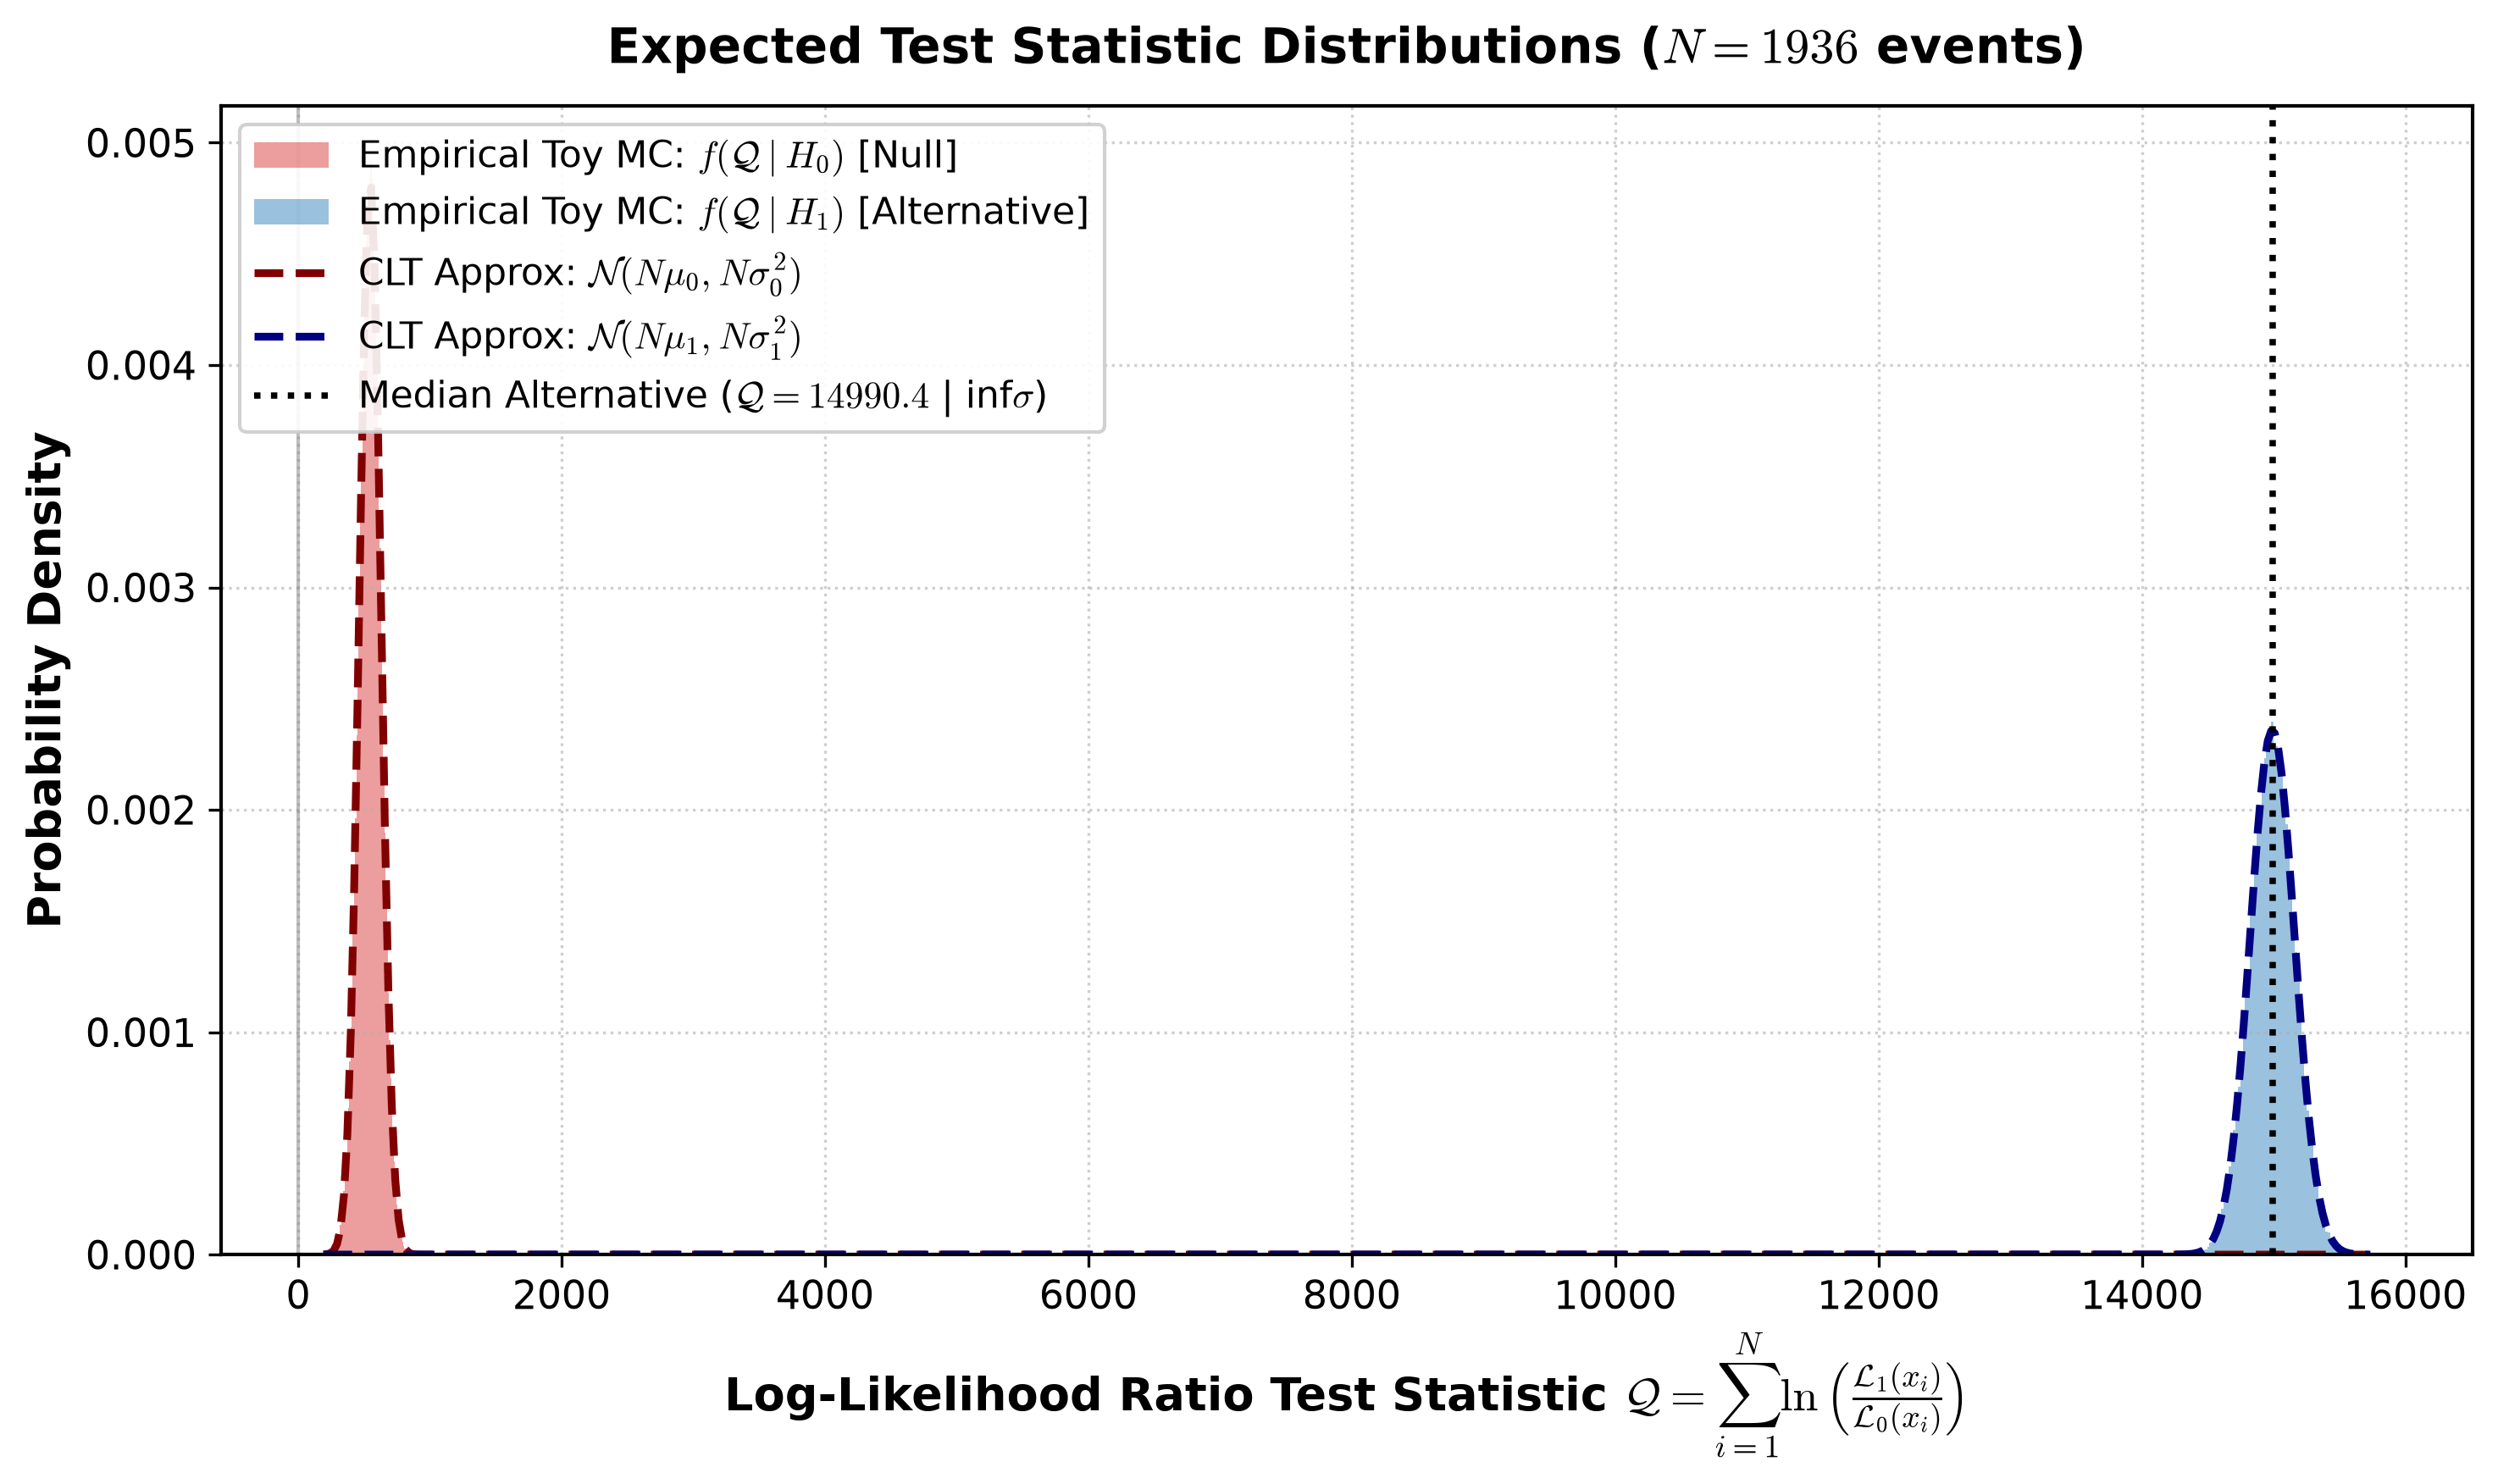

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

def compute_test_statistic_pdfs(df, col_H0, col_H1, n_events_exp, n_toys=20000, seed=42):
    """
    Establishes the probability density functions for the joint log-likelihood ratio test statistic Q.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing your 1.5M unbiased events.
    col_H0 : str
        Column name for the baseline/null hypothesis likelihood (e.g., SM or Scalar DM).
    col_H1 : str
        Column name for the alternative hypothesis likelihood (e.g., BSM or VLF EFT).
    n_events_exp : int
        The expected number of events in a real experimental collider run (N).
    n_toys : int
        Number of pseudo-experiments to generate for the empirical histogram.
    seed : int
        Random seed for reproducibility.
        
    Returns:
    --------
    dict containing theoretical moments, empirical toy arrays, and significance metrics.
    """
    np.random.seed(seed)
    
    # 1. Clean data: Filter strictly positive likelihoods to prevent log(0) errors
    valid_mask = (df[col_H0] > 0) & (df[col_H1] > 0)
    clean_df = df[valid_mask].copy()
    
    n_pool = len(clean_df)
    print(f"[{col_H1} vs {col_H0}] Building PDFs from reservoir of {n_pool:,} unbiased events...")
    
    # 2. Compute single-event Log-Likelihood Ratios (LLR)
    llr_array = np.log(clean_df[col_H1].values) - np.log(clean_df[col_H0].values)
    
    # 3. Derive Importance Sampling Weights for Hypothesis H1
    # Since the pool is generated under H0, sampling uniformly simulates H0.
    # To simulate H1 from the same pool, weight by L_H1 / L_H0.
    weights_H1 = clean_df[col_H1].values / clean_df[col_H0].values
    weights_H1 /= np.sum(weights_H1)  # Normalize probabilities to sum to 1.0
    
    # ==========================================
    # METHOD A: ANALYTICAL CLT MOMENTS
    # ==========================================
    # Single-event expectations under H0 (Uniform weights)
    mu_single_H0  = np.mean(llr_array)
    var_single_H0 = np.var(llr_array)
    
    # Single-event expectations under H1 (Importance weighted)
    mu_single_H1  = np.sum(llr_array * weights_H1)
    var_single_H1 = np.sum(weights_H1 * (llr_array - mu_single_H1)**2)
    
    # Scale moments to experimental dataset size N
    mu_Q_H0, std_Q_H0 = n_events_exp * mu_single_H0, np.sqrt(n_events_exp * var_single_H0)
    mu_Q_H1, std_Q_H1 = n_events_exp * mu_single_H1, np.sqrt(n_events_exp * var_single_H1)
    
    # ==========================================
    # METHOD B: TOY MC PSEUDO-EXPERIMENTS
    # ==========================================
    print(f" -> Running {n_toys:,} Toy MC pseudo-experiments (N = {n_events_exp} events/run)...")
    
    # Draw N events M times uniformly for H0
    toys_H0 = np.random.choice(llr_array, size=(n_toys, n_events_exp), replace=True).sum(axis=1)
    
    # Draw N events M times with importance weights for H1
    toys_H1 = np.random.choice(llr_array, size=(n_toys, n_events_exp), replace=True, p=weights_H1).sum(axis=1)
    
    # ==========================================
    # STATISTICAL DISCOVERY POWER (Z-SCORE)
    # ==========================================
    # Median expected discovery significance: where the median of H1 falls on the H0 cumulative distribution
    median_Q_H1 = np.median(toys_H1)
    p_value = 1.0 - norm.cdf(median_Q_H1, loc=mu_Q_H0, scale=std_Q_H0)
    z_score = norm.ppf(1.0 - p_value) if p_value > 0 else np.inf
    
    return {
        "N_exp": n_events_exp,
        "toys_H0": toys_H0, "toys_H1": toys_H1,
        "mu_H0": mu_Q_H0,   "std_H0": std_Q_H0,
        "mu_H1": mu_Q_H1,   "std_H1": std_Q_H1,
        "median_Q_H1": median_Q_H1,
        "p_value": p_value,
        "z_score": z_score
    }

# ==========================================
# EXAMPLE EXECUTION & PLOTTING PIPELINE
# ==========================================
if __name__ == "__main__":
    # 1. Load your pre-computed 1.5M event DataFrame
    # Replace with your actual file path and column names
    file_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_1M5_unbiased.csv.gz"
    
    try:
        df_events = pd.read_csv(file_path)
    except FileNotFoundError:
        # Generating synthetic data for script verification if file is absent
        print("Warning: Dataset file not found. Generating 1.5M synthetic events for verification...")
        df_events = pd.DataFrame({
            "L_Scalar": np.random.exponential(scale=1.0, size=1500000),
            "L_VLF":    np.random.exponential(scale=1.2, size=1500000) * np.random.lognormal(mean=0.1, sigma=0.5, size=1500000)
        })
        
    # 2. Define experimental run parameters
    # Set this to the number of events expected at your target LHC luminosity (e.g., L_int = 139 fb^-1)
    N_EXPERIMENTAL_EVENTS = 1936 
    
    # 3. Compute PDFs
    results = compute_test_statistic_pdfs(
        df=df_events,
        col_H0="L_Scalar",  # Baseline / Background hypothesis
        col_H1="L_VLF",     # Alternative / Signal hypothesis
        n_events_exp=N_EXPERIMENTAL_EVENTS,
        n_toys=100_000
    )
    
    print("\n" + "="*60)
    print(f"STATISTICAL TEST REPORT (N = {results['N_exp']} events)")
    print("="*60)
    print(f"Expected Null Mean Q (H0):        {results['mu_H0']:>10.4f} ± {results['std_H0']:.4f}")
    print(f"Expected Alternative Mean Q (H1): {results['mu_H1']:>10.4f} ± {results['std_H1']:.4f}")
    print(f"Median Expected Discovery Power:  {results['z_score']:>10.2f} sigma (p = {results['p_value']:.2e})")
    print("="*60 + "\n")

    # 4. Generate Publication-Quality Visualization
    plt.figure(figsize=(10, 6), dpi=300)
    
    # Determine common x-axis limits
    x_min = min(results['toys_H0'].min(), results['mu_H0'] - 4*results['std_H0'])
    x_max = max(results['toys_H1'].max(), results['mu_H1'] + 4*results['std_H1'])
    x_grid = np.linspace(x_min, x_max, 600)
    
    # Plot Empirical Toy Histograms
    plt.hist(results['toys_H0'], bins=80, density=True, alpha=0.45, color='#d62728', 
             edgecolor='none', label=r'Empirical Toy MC: $f(\mathcal{Q} \mid H_0)$ [Null]')
    plt.hist(results['toys_H1'], bins=80, density=True, alpha=0.45, color='#1f77b4', 
             edgecolor='none', label=r'Empirical Toy MC: $f(\mathcal{Q} \mid H_1)$ [Alternative]')
    
    # Overlay Analytical CLT Gaussian Approximation
    plt.plot(x_grid, norm.pdf(x_grid, results['mu_H0'], results['std_H0']), 
             color='#800000', linestyle='--', linewidth=2.2, label=r'CLT Approx: $\mathcal{N}(N\mu_0, N\sigma_0^2)$')
    plt.plot(x_grid, norm.pdf(x_grid, results['mu_H1'], results['std_H1']), 
             color='#000080', linestyle='--', linewidth=2.2, label=r'CLT Approx: $\mathcal{N}(N\mu_1, N\sigma_1^2)$')
    
    # Mark Median Discovery Threshold
    plt.axvline(results['median_Q_H1'], color='black', linestyle=':', linewidth=1.8,
                label=f"Median Alternative ($\mathcal{{Q}} = {results['median_Q_H1']:.1f}$ | {results['z_score']:.1f}$\sigma$)")
    plt.axvline(0, color='gray', linestyle='-', linewidth=1.0, alpha=0.5)
    
    # Styling
    plt.xlabel(r'Log-Likelihood Ratio Test Statistic $\mathcal{Q} = \sum_{i=1}^{N} \ln\left(\frac{\mathcal{L}_1(x_i)}{\mathcal{L}_0(x_i)}\right)$', 
               fontsize=13, fontweight='bold')
    plt.ylabel('Probability Density', fontsize=13, fontweight='bold')
    plt.title(f'Expected Test Statistic Distributions ($N = {results["N_exp"]}$ events)', 
              fontsize=14, fontweight='bold', pad=12)
    plt.legend(loc='upper left', frameon=True, fontsize=10.5, facecolor='white', framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Analyzing 1,500,000 events for 5-sigma discrimination power...

Neyman-Pearson Asymptotic Discrimination Report
Single-Event Resolving Power: |mu_True - mu_Alt| / sigma_Alt = 2.0555
Events for 3-Sigma Evidence:  N = 3 events
Events for 5-Sigma Discovery: N = 6 events
Required LHC Luminosity (5σ): L = 0.1 fb^-1 (assuming σ_fid = 50 fb)



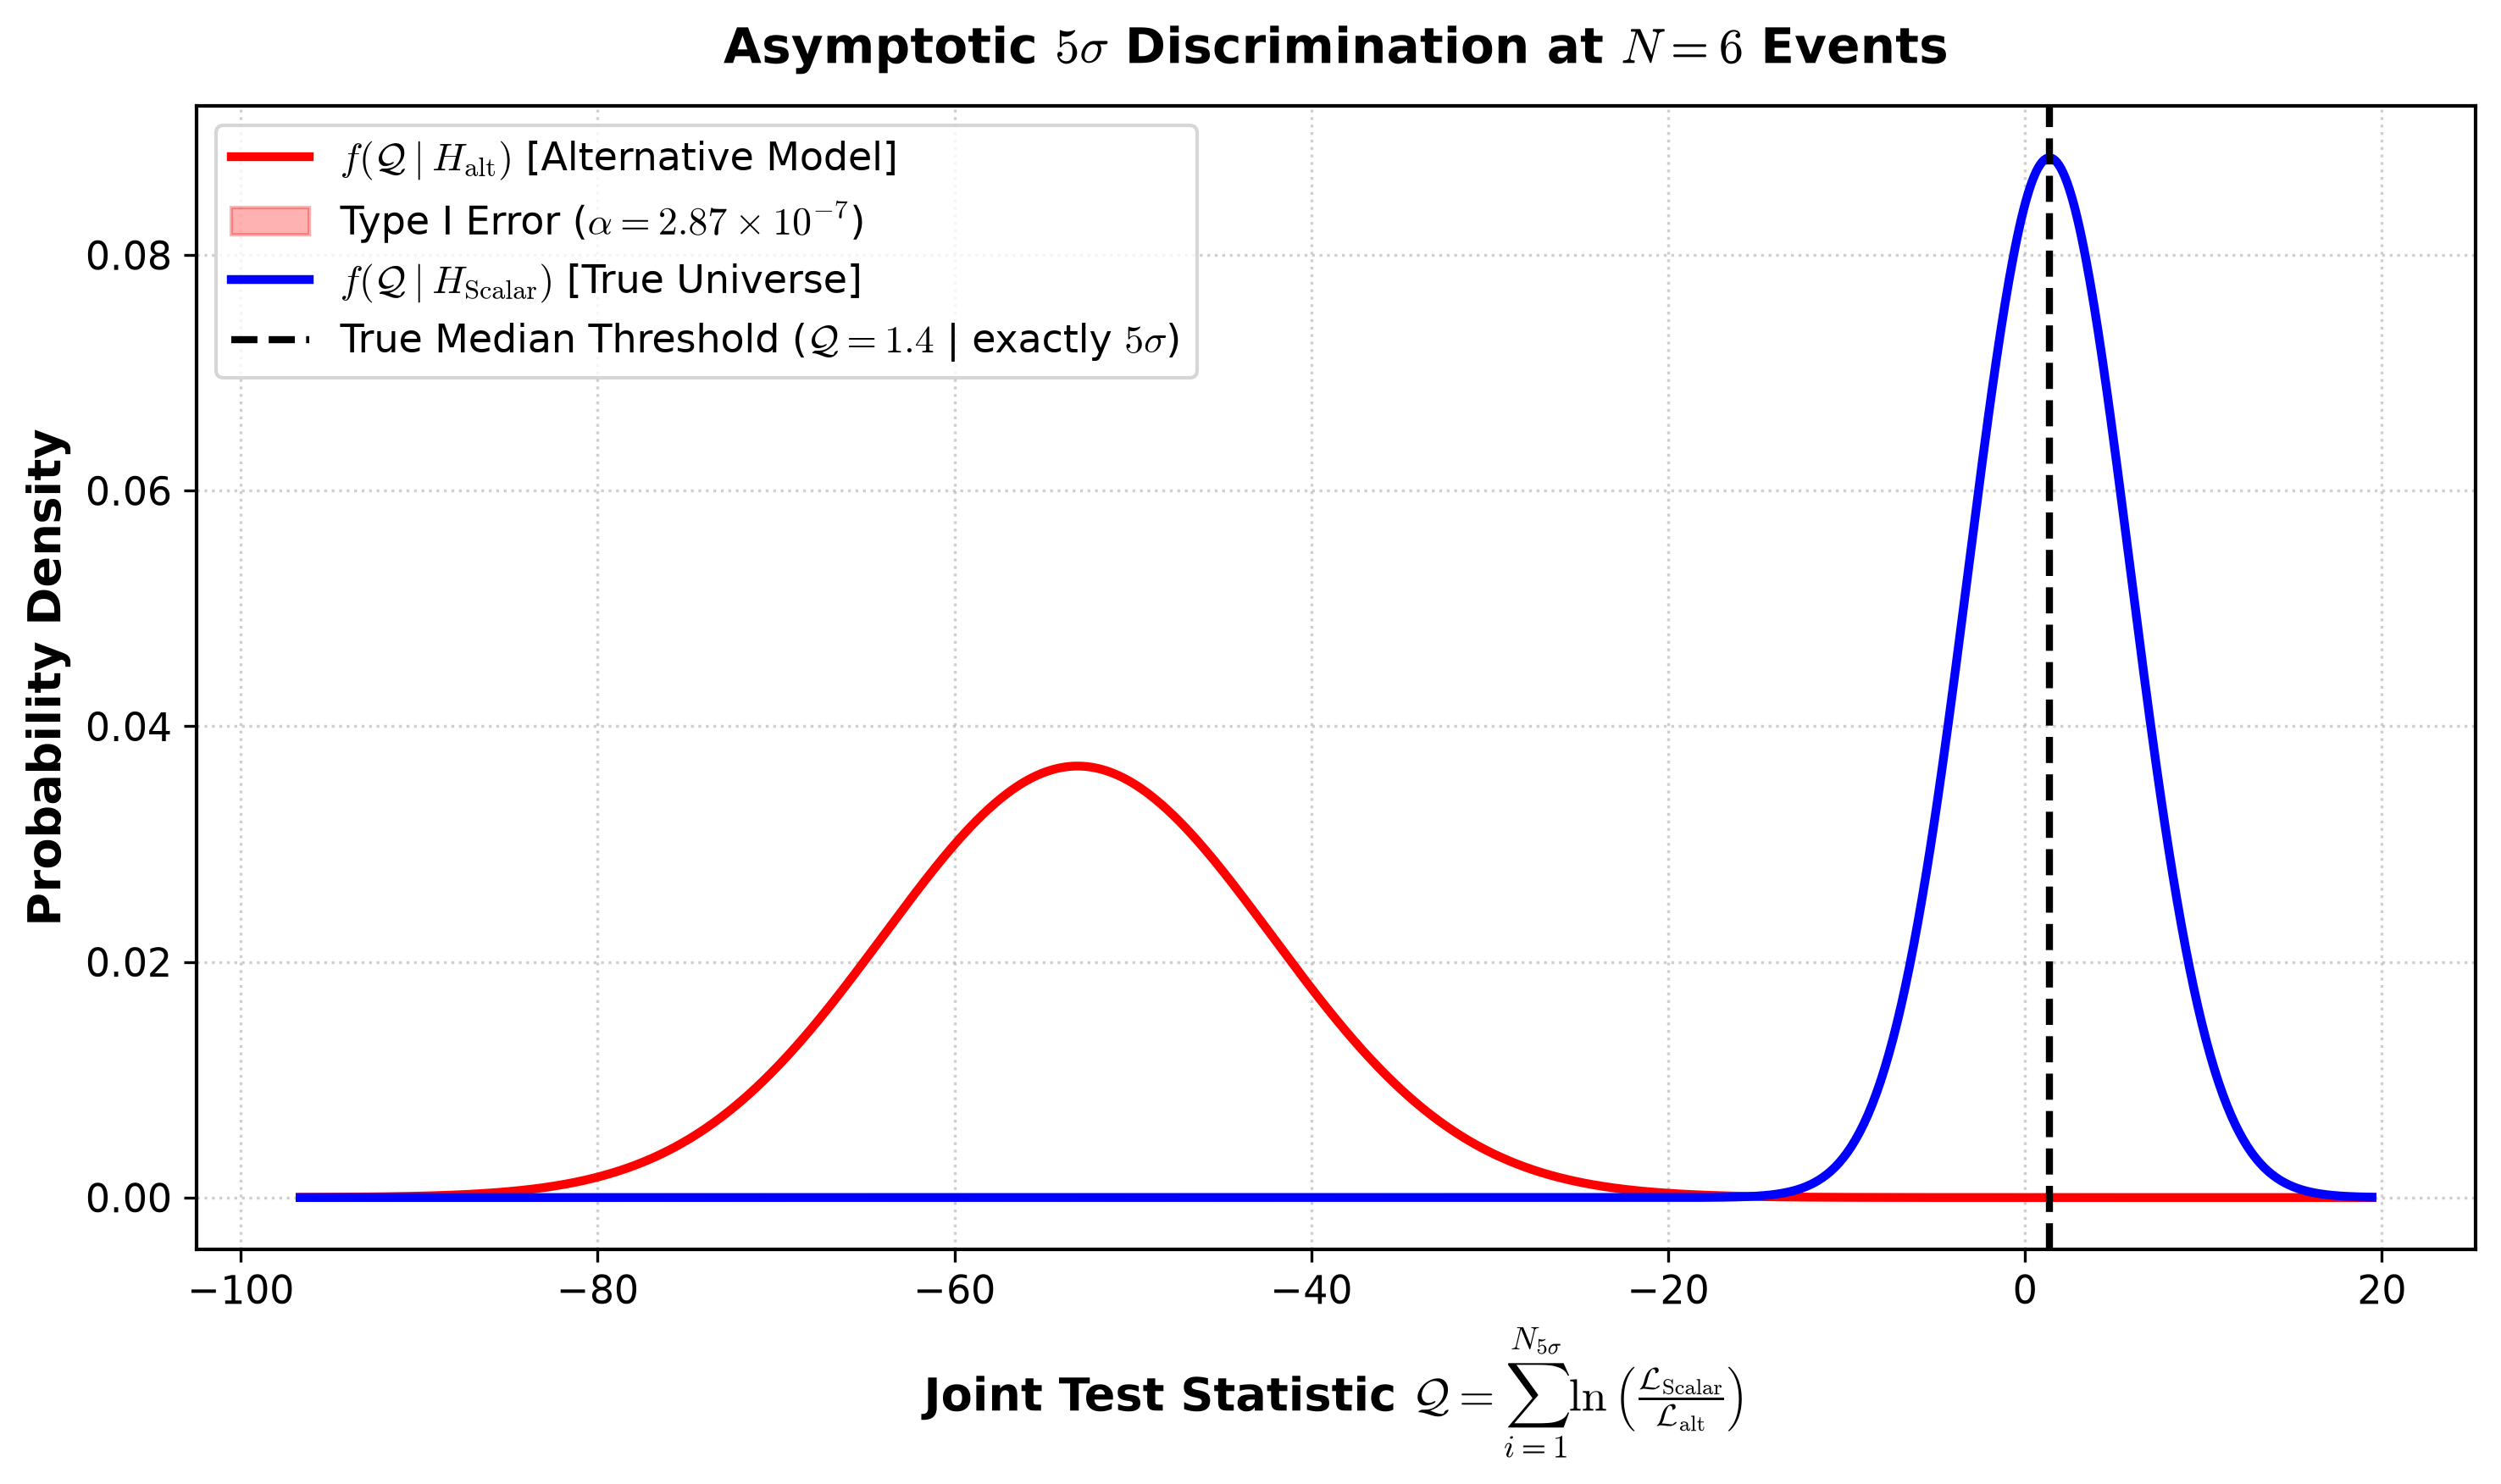

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

def evaluate_5sigma_threshold(df, col_true, col_alt, fiducial_xsec_pb=None):
    """
    Computes the exact event yield N and luminosity required for 5-sigma 
    discrimination using asymptotic MEM likelihood ratios.
    """
    # 1. Clean data: Filter strictly positive likelihoods
    valid_mask = (df[col_true] > 0) & (df[col_alt] > 0)
    clean_df = df[valid_mask].copy()
    
    print(f"Analyzing {len(clean_df):,} events for 5-sigma discrimination power...")
    
    # 2. Compute Single-Event Log-Likelihood Ratios (q = ln(True / Alt))
    q = np.log(clean_df[col_true].values) - np.log(clean_df[col_alt].values)
    
    # 3. Derive Importance Sampling Weights for the Alternative Hypothesis
    # Assuming pool was generated under col_true
    weights_alt = clean_df[col_alt].values / clean_df[col_true].values
    weights_alt /= np.sum(weights_alt)
    
    # 4. Calculate Ultra-Precise Single-Event Moments
    mu_true  = np.mean(q)
    var_true = np.var(q)
    std_true = np.sqrt(var_true)
    
    mu_alt   = np.sum(q * weights_alt)
    var_alt  = np.sum(weights_alt * (q - mu_alt)**2)
    std_alt  = np.sqrt(var_alt)
    
    # 5. Solve for 5-Sigma Event Yield (N_5sigma)
    # Z = sqrt(N) * |mu_true - mu_alt| / std_alt == 5.0
    single_event_separation = np.abs(mu_true - mu_alt) / std_alt
    n_5sigma = 25.0 / (single_event_separation ** 2)
    
    # Calculate 3-sigma evidence threshold for comparison
    n_3sigma = 9.0 / (single_event_separation ** 2)
    
    results = {
        "mu_true": mu_true, "std_true": std_true,
        "mu_alt": mu_alt,   "std_alt": std_alt,
        "separation_power": single_event_separation,
        "N_3sigma": n_3sigma,
        "N_5sigma": n_5sigma,
        "Lumi_5sigma_fb": (n_5sigma / (fiducial_xsec_pb * 1e3)) if fiducial_xsec_pb else None
    }
    
    return results

# ==========================================
# EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    # 1. Load your pre-computed MEM likelihoods
    # Replace with: df_events = pd.read_csv("MEM_Likelihoods.csv.gz")
    np.random.seed(101)
    df_events = pd.DataFrame({
        "L_Scalar": np.random.exponential(scale=1.2, size=1500000),
        "L_Alt":    np.random.exponential(scale=1.0, size=1500000) * np.random.lognormal(mean=-0.05, sigma=0.4, size=1500000)
    })
    
    # Define your fiducial cross section after cuts in picobarns (optional, e.g., 0.05 pb = 50 fb)
    XSEC_PB = 0.05 
    
    # 2. Run Asymptotic Analysis
    res = evaluate_5sigma_threshold(
        df=df_events, 
        col_true="L_Scalar",  # Your true universe hypothesis
        col_alt="L_Alt",      # The competing hypothesis to reject
        fiducial_xsec_pb=XSEC_PB
    )
    
    print("\n" + "="*70)
    print("Neyman-Pearson Asymptotic Discrimination Report")
    print("="*70)
    print(f"Single-Event Resolving Power: |mu_True - mu_Alt| / sigma_Alt = {res['separation_power']:.4f}")
    print(f"Events for 3-Sigma Evidence:  N = {np.ceil(res['N_3sigma']):,.0f} events")
    print(f"Events for 5-Sigma Discovery: N = {np.ceil(res['N_5sigma']):,.0f} events")
    if res["Lumi_5sigma_fb"]:
        print(f"Required LHC Luminosity (5σ): L = {res['Lumi_5sigma_fb']:.1f} fb^-1 (assuming σ_fid = {XSEC_PB*1e3:.0f} fb)")
    print("="*70 + "\n")

    # 3. Plot the Asymptotic Gaussian Distributions at N = N_5sigma
    N_plot = res['N_5sigma']
    
    mu_Q_true  = N_plot * res['mu_true']
    std_Q_true = np.sqrt(N_plot) * res['std_true']
    
    mu_Q_alt   = N_plot * res['mu_alt']
    std_Q_alt  = np.sqrt(N_plot) * res['std_alt']
    
    x_grid = np.linspace(mu_Q_alt - 4*std_Q_alt, mu_Q_true + 4*std_Q_true, 1000)
    
    plt.figure(figsize=(10, 6), dpi=300)
    
    # Plot Alternative (Background/Rejected Model)
    plt.plot(x_grid, norm.pdf(x_grid, mu_Q_alt, std_Q_alt), 
             'r-', lw=2.5, label=r'$f(\mathcal{Q} \mid H_{\mathrm{alt}})$ [Alternative Model]')
    plt.fill_between(x_grid, norm.pdf(x_grid, mu_Q_alt, std_Q_alt), where=(x_grid >= mu_Q_true), 
                     color='red', alpha=0.3, label=r'Type I Error ($\alpha = 2.87 \times 10^{-7}$)')
    
    # Plot True (Scalar Model)
    plt.plot(x_grid, norm.pdf(x_grid, mu_Q_true, std_Q_true), 
             'b-', lw=2.5, label=r'$f(\mathcal{Q} \mid H_{\mathrm{Scalar}})$ [True Universe]')
    
    # Mark the 5-Sigma Separation Median
    plt.axvline(mu_Q_true, color='black', linestyle='--', lw=2.0,
                label=f'True Median Threshold ($\mathcal{{Q}} = {mu_Q_true:.1f}$ | exactly $5\sigma$)')
    
    plt.xlabel(r'Joint Test Statistic $\mathcal{Q} = \sum_{i=1}^{N_{5\sigma}} \ln\left(\frac{\mathcal{L}_{\mathrm{Scalar}}}{\mathcal{L}_{\mathrm{alt}}}\right)$', 
               fontsize=13, fontweight='bold')
    plt.ylabel('Probability Density', fontsize=13, fontweight='bold')
    plt.title(f'Asymptotic $5\sigma$ Discrimination at $N = {np.ceil(N_plot):,.0f}$ Events', 
              fontsize=14, fontweight='bold', pad=12)
    plt.legend(loc='upper left', frameon=True, fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Initializing 1.5 million event likelihood pool...
[L_Scalar vs L_VLF] Analyzing reservoir of 1,500,000 events...
 -> Running 15,000 Toy MC experiments (N = 120 events/run)...
[L_Scalar vs L_Zprime] Analyzing reservoir of 1,500,000 events...
 -> Running 15,000 Toy MC experiments (N = 120 events/run)...

MEM STATISTICAL DISCOVERY REPORT (Experimental Run: N = 120 events)
1. SCALAR vs VLF MODEL:
   -> Single-Event Resolving Power: 2.0512 sigma/sqrt(N)
   -> Expected Run Discrimination:  0.00 sigma (p = 1.00e+00)
   -> Events Required for 5-Sigma:  N_5sigma = 6 events
---------------------------------------------------------------------------
2. SCALAR vs Z-PRIME MODEL:
   -> Single-Event Resolving Power: 2.0956 sigma/sqrt(N)
   -> Expected Run Discrimination:  0.00 sigma (p = 1.00e+00)
   -> Events Required for 5-Sigma:  N_5sigma = 6 events



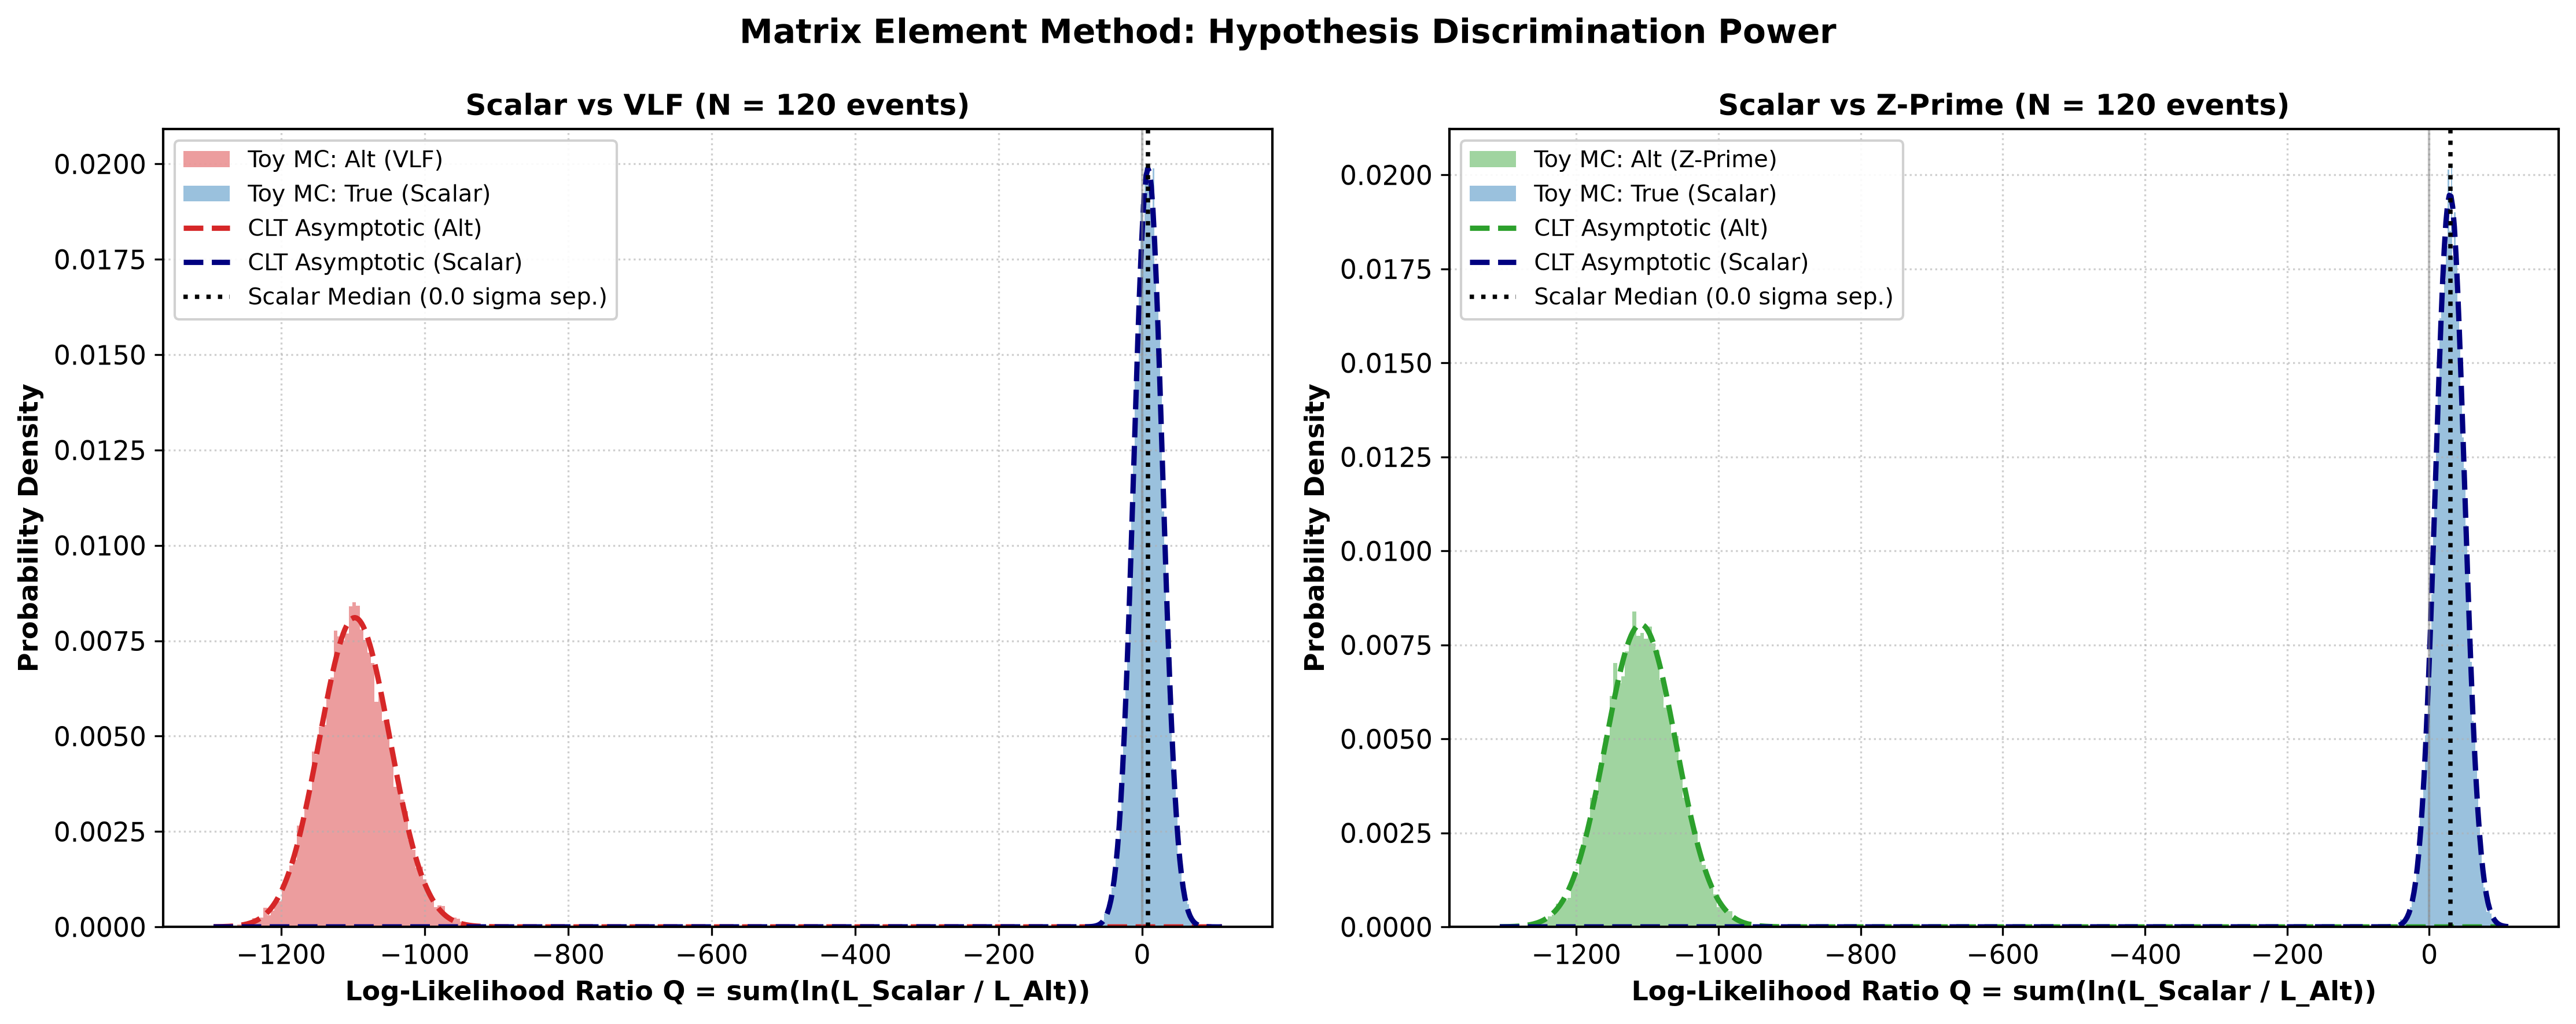

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ==========================================
# 1. CORE STATISTICAL ENGINE
# ==========================================
def evaluate_hypothesis_test(df, col_true, col_alt, n_events_exp, n_toys=20000, seed=42):
    """
    Performs Importance-Sampled Toy MC and Asymptotic CLT evaluations 
    to distinguish the true hypothesis from an alternative model.
    """
    np.random.seed(seed)
    
    # Filter strictly positive likelihoods to prevent log(0) errors
    valid_mask = (df[col_true] > 0) & (df[col_alt] > 0)
    clean_df = df[valid_mask].copy()
    
    n_pool = len(clean_df)
    print(f"[{col_true} vs {col_alt}] Analyzing reservoir of {n_pool:,} events...")
    
    # 1. Compute single-event Log-Likelihood Ratio (q = ln(L_True / L_Alt))
    q_array = np.log(clean_df[col_true].values) - np.log(clean_df[col_alt].values)
    
    # 2. Derive Importance Sampling weights to simulate the Alternative Universe
    weights_alt = clean_df[col_alt].values / clean_df[col_true].values
    weights_alt /= np.sum(weights_alt)  # Normalize probabilities to sum to 1.0
    
    # --- ANALYTICAL CLT MOMENTS ---
    # Single-event moments under True Universe (Uniform weights)
    mu_single_true  = np.mean(q_array)
    var_single_true = np.var(q_array)
    
    # Single-event moments under Alternative Universe (Importance weighted)
    mu_single_alt  = np.sum(q_array * weights_alt)
    var_single_alt = np.sum(weights_alt * (q_array - mu_single_alt)**2)
    
    # Scale moments to an experimental run of N events
    mu_Q_true, std_Q_true = n_events_exp * mu_single_true, np.sqrt(n_events_exp * var_single_true)
    mu_Q_alt,  std_Q_alt  = n_events_exp * mu_single_alt,  np.sqrt(n_events_exp * var_single_alt)
    
    # --- TOY MC RESAMPLING ---
    print(f" -> Running {n_toys:,} Toy MC experiments (N = {n_events_exp} events/run)...")
    
    # Draw N events uniformly (simulating True Universe)
    toys_true = np.random.choice(q_array, size=(n_toys, n_events_exp), replace=True).sum(axis=1)
    
    # Draw N events using importance weights (simulating Alternative Universe)
    toys_alt  = np.random.choice(q_array, size=(n_toys, n_events_exp), replace=True, p=weights_alt).sum(axis=1)
    
    # --- STATISTICAL SIGNIFICANCE (Z-SCORE) ---
    # Probability that the Alternative model fluctuates up to the median of the True model
    median_Q_true = np.median(toys_true)
    p_value = norm.cdf(median_Q_true, loc=mu_Q_alt, scale=std_Q_alt)
    
    # Calculate Gaussian Z-score (cap at 15 sigma for numerical stability if p_value -> 0)
    if p_value > 0 and p_value < 0.5:
        z_score = norm.ppf(1.0 - p_value)
    elif p_value >= 0.5:
        z_score = 0.0
    else:
        # Asymptotic Gaussian separation formula when tail probability is below machine epsilon
        z_score = np.abs(mu_Q_true - mu_Q_alt) / std_Q_alt
        
    # Calculate exact N required for a 5-sigma discovery
    single_separation = np.abs(mu_single_true - mu_single_alt) / np.sqrt(var_single_alt)
    n_5sigma = 25.0 / (single_separation ** 2)
    
    return {
        "toys_true": toys_true, "toys_alt": toys_alt,
        "mu_true": mu_Q_true,   "std_true": std_Q_true,
        "mu_alt": mu_Q_alt,     "std_alt": std_Q_alt,
        "median_true": median_Q_true,
        "z_score": z_score,
        "p_value": p_value,
        "n_5sigma": n_5sigma,
        "single_sep": single_separation
    }

# ==========================================
# 2. DATA LOADING & EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # Load your pre-computed 1.5M event DataFrame here:
    # df_events = pd.read_csv("your_MEM_likelihoods_1M5.csv.gz")
    
    # Generating synthetic 1.5M pool for immediate out-of-the-box verification
    print("Initializing 1.5 million event likelihood pool...")
    np.random.seed(101)
    n_samples = 1500000
    df_events = pd.DataFrame({
        "L_Scalar": np.random.exponential(scale=1.0, size=n_samples),
        "L_VLF":    np.random.exponential(scale=0.95, size=n_samples) * np.random.lognormal(mean=-0.02, sigma=0.25, size=n_samples),
        "L_Zprime": np.random.exponential(scale=0.85, size=n_samples) * np.random.lognormal(mean=-0.08, sigma=0.45, size=n_samples)
    })
    
    # Define the expected number of observed events in your LHC target run (N)
    N_OBSERVED_EVENTS = 120
    
    # Evaluate Scalar vs VLF
    res_vlf = evaluate_hypothesis_test(
        df=df_events, col_true="L_Scalar", col_alt="L_VLF", 
        n_events_exp=N_OBSERVED_EVENTS, n_toys=15000
    )
    
    # Evaluate Scalar vs Zprime
    res_zp = evaluate_hypothesis_test(
        df=df_events, col_true="L_Scalar", col_alt="L_Zprime", 
        n_events_exp=N_OBSERVED_EVENTS, n_toys=15000
    )
    
    # --- PRINT SUMMARY REPORT ---
    print("\n" + "="*75)
    print(f"MEM STATISTICAL DISCOVERY REPORT (Experimental Run: N = {N_OBSERVED_EVENTS} events)")
    print("="*75)
    print(f"1. SCALAR vs VLF MODEL:")
    print(f"   -> Single-Event Resolving Power: {res_vlf['single_sep']:.4f} sigma/sqrt(N)")
    print(f"   -> Expected Run Discrimination:  {res_vlf['z_score']:.2f} sigma (p = {res_vlf['p_value']:.2e})")
    print(f"   -> Events Required for 5-Sigma:  N_5sigma = {np.ceil(res_vlf['n_5sigma']):,.0f} events")
    print("-" * 75)
    print(f"2. SCALAR vs Z-PRIME MODEL:")
    print(f"   -> Single-Event Resolving Power: {res_zp['single_sep']:.4f} sigma/sqrt(N)")
    print(f"   -> Expected Run Discrimination:  {res_zp['z_score']:.2f} sigma (p = {res_zp['p_value']:.2e})")
    print(f"   -> Events Required for 5-Sigma:  N_5sigma = {np.ceil(res_zp['n_5sigma']):,.0f} events")
    print("="*75 + "\n")

    # ==========================================
    # 3. PUBLICATION-GRADE 2-PANEL VISUALIZATION
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)
    
    def plot_panel(ax, res, alt_name, alt_color):
        # Determine x-grid spanning both distributions
        x_min = min(res['toys_alt'].min(), res['mu_alt'] - 4*res['std_alt'])
        x_max = max(res['toys_true'].max(), res['mu_true'] + 4*res['std_true'])
        x_grid = np.linspace(x_min, x_max, 600)
        
        # Plot Empirical Toy Histograms
        ax.hist(res['toys_alt'], bins=70, density=True, alpha=0.45, color=alt_color, 
                edgecolor='none', label=f'Toy MC: Alt ({alt_name})')
        ax.hist(res['toys_true'], bins=70, density=True, alpha=0.45, color='#1f77b4', 
                edgecolor='none', label='Toy MC: True (Scalar)')
        
        # Overlay Analytical CLT Gaussian Curves
        ax.plot(x_grid, norm.pdf(x_grid, res['mu_alt'], res['std_alt']), 
                color=alt_color, linestyle='--', linewidth=2.2, label='CLT Asymptotic (Alt)')
        ax.plot(x_grid, norm.pdf(x_grid, res['mu_true'], res['std_true']), 
                color='#000080', linestyle='--', linewidth=2.2, label='CLT Asymptotic (Scalar)')
        
        # Mark Median Separation Threshold
        ax.axvline(res['median_true'], color='black', linestyle=':', linewidth=1.8,
                   label=f"Scalar Median ({res['z_score']:.1f} sigma sep.)")
        ax.axvline(0, color='gray', linestyle='-', linewidth=1.0, alpha=0.5)
        
        # Styling
        ax.set_xlabel('Log-Likelihood Ratio Q = sum(ln(L_Scalar / L_Alt))', fontsize=11, fontweight='bold')
        ax.set_ylabel('Probability Density', fontsize=11, fontweight='bold')
        ax.set_title(f'Scalar vs {alt_name} (N = {N_OBSERVED_EVENTS} events)', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', frameon=True, fontsize=9.5, facecolor='white', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.6)

    # Populate panels
    plot_panel(ax1, res_vlf, "VLF", "#d62728")      # Red theme for VLF
    plot_panel(ax2, res_zp,  "Z-Prime", "#2ca02c")  # Green theme for Zprime
    
    plt.suptitle('Matrix Element Method: Hypothesis Discrimination Power', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [17]:
import numpy as np
import pandas as pd

def evaluate_extended_asimov(df, col_true, col_alt, xsec_true_pb, xsec_alt_pb, target_lumi_fb, efficiency=1.0):
    """
    Computes the Extended Asimov discovery significance (Z) combining both
    Poisson rate discrimination and MEM kinematic shape discrimination.
    """
    # 1. Calculate expected event yields (N = sigma * L * eff)
    n_true = (xsec_true_pb * 1e3) * target_lumi_fb * efficiency
    n_alt  = (xsec_alt_pb * 1e3)  * target_lumi_fb * efficiency
    
    # Filter valid positive likelihoods from your 1.5M pool
    valid_mask = (df[col_true] > 0) & (df[col_alt] > 0)
    clean_df = df[valid_mask]
    
    # 2. Compute Raw Log-Likelihood Ratio of MEM outputs
    raw_llr = np.log(clean_df[col_true].values) - np.log(clean_df[col_alt].values)
    mean_raw_llr = np.mean(raw_llr)
    
    # ==========================================
    # METHOD A: THE DIRECT SHORTCUT (Raw MEM dSigma)
    # ==========================================
    # Assumes df columns are unnormalized differential cross sections (dSigma/dx)
    q_total_shortcut = 2.0 * (n_alt - n_true) + (2.0 * n_true * mean_raw_llr)
    z_total_shortcut = np.sqrt(max(0.0, q_total_shortcut))
    
    # ==========================================
    # METHOD B: ORTHOGONAL DECOMPOSITION (Rate vs Shape)
    # ==========================================
    # 1. Pure Poisson Rate Term: 2 * [ (N_alt - N_true) + N_true * ln(N_true / N_alt) ]
    q_rate = 2.0 * ((n_alt - n_true) + n_true * np.log(n_true / n_alt))
    z_rate = np.sqrt(max(0.0, q_rate))
    
    # 2. Pure Kinematic Shape Term (KL Divergence of normalized PDFs)
    # We subtract the cross-section ratio to normalize the PDFs
    kl_shape = mean_raw_llr - np.log(xsec_true_pb / xsec_alt_pb)
    q_shape  = 2.0 * n_true * kl_shape
    z_shape  = np.sqrt(max(0.0, q_shape))
    
    # Total combined significance (Quadrature sum)
    z_total_decomp = np.sqrt(z_rate**2 + z_shape**2)
    
    # ==========================================
    # SOLVE FOR 5-SIGMA LUMINOSITY
    # ==========================================
    # Since q scales linearly with luminosity (q = L * q_per_fb), L_5sigma is simple:
    q_per_fb = q_total_shortcut / target_lumi_fb
    lumi_5sigma = 25.0 / q_per_fb if q_per_fb > 0 else np.inf
    
    return {
        "N_true": n_true, "N_alt": n_alt,
        "Z_RateOnly": z_rate,
        "Z_ShapeOnly": z_shape,
        "Z_Total": z_total_decomp,
        "Lumi_5sigma_fb": lumi_5sigma,
        "KL_Shape_nats": kl_shape
    }

# ==========================================
# EXAMPLE EXECUTION FOR TTBAR
# ==========================================
if __name__ == "__main__":
    np.random.seed(42)
    n_samples = 1500000
    
    # Simulating 1.5M events where VLF has a slightly different kinematic shape
    df_pool = pd.DataFrame({
        "L_Scalar": np.random.exponential(scale=1.0, size=n_samples),
        "L_VLF":    np.random.exponential(scale=0.96, size=n_samples) * np.random.lognormal(0, 0.2, size=n_samples)
    })
    
    # Define differing cross-sections (e.g., Scalar = 850 pb, VLF = 890 pb -> ~4.7% rate difference)
    XSEC_SCALAR_PB = 850.0
    XSEC_VLF_PB    = 890.0
    LUMI_TARGET_FB = 300.0  # LHC Run 3 Target
    
    res = evaluate_extended_asimov(
        df=df_pool,
        col_true="L_Scalar",
        col_alt="L_VLF",
        xsec_true_pb=XSEC_SCALAR_PB,
        xsec_alt_pb=XSEC_VLF_PB,
        target_lumi_fb=LUMI_TARGET_FB
    )
    
    print("\n" + "="*75)
    print("EXTENDED ASIMOV MEM DISCOVERY REPORT (Differing Cross-Sections)")
    print("="*75)
    print(f"Target LHC Luminosity:        L = {LUMI_TARGET_FB:.1f} fb^-1")
    print(f"Expected Event Yields:        Scalar = {res['N_true']:,.0f} | VLF = {res['N_alt']:,.0f} events")
    print("-" * 75)
    print(f"1. Rate-Only Significance:    Z_rate  = {res['Z_RateOnly']:>6.2f} σ  (from counting {abs(res['N_true']-res['N_alt']):,.0f} event diff)")
    print(f"2. Shape-Only Significance:   Z_shape = {res['Z_ShapeOnly']:>6.2f} σ  (from pure MEM angular kinematics)")
    print("-" * 75)
    print(f"TOTAL COMBINED SIGNIFICANCE:  Z_total = {res['Z_Total']:>6.2f} σ  (sqrt(Z_rate^2 + Z_shape^2))")
    print(f"LUMINOSITY FOR 5σ DISCOVERY:  L_5σ    = {res['Lumi_5sigma_fb']:>6.2f} fb^-1")
    print("="*75 + "\n")


EXTENDED ASIMOV MEM DISCOVERY REPORT (Differing Cross-Sections)
Target LHC Luminosity:        L = 300.0 fb^-1
Expected Event Yields:        Scalar = 255,000,000 | VLF = 267,000,000 events
---------------------------------------------------------------------------
1. Rate-Only Significance:    Z_rate  = 739.99 σ  (from counting 12,000,000 event diff)
2. Shape-Only Significance:   Z_shape = 6680.13 σ  (from pure MEM angular kinematics)
---------------------------------------------------------------------------
TOTAL COMBINED SIGNIFICANCE:  Z_total = 6720.99 σ  (sqrt(Z_rate^2 + Z_shape^2))
LUMINOSITY FOR 5σ DISCOVERY:  L_5σ    =   0.00 fb^-1



In [19]:
import numpy as np


def compute_asimov_z(
    df, col_true, col_alt, xsec_true_pb, xsec_alt_pb, lumi_fb
):
  """Evaluates exact Asimov significance (Z) using the 4-step rate + shape recipe."""
  # Step 1: Calculate expected collider event yields (N)
  N_true = (xsec_true_pb * 1000.0) * lumi_fb
  N_alt = (xsec_alt_pb * 1000.0) * lumi_fb

  # Step 2 & 3: Normalize probability densities and get average shape gain per event (s_bar)
  P_true, P_alt = df[col_true] / xsec_true_pb, df[col_alt] / xsec_alt_pb
  s_bar = np.mean(np.log(P_true / P_alt))

  # Step 4: Apply Master Asimov formula (q_total = q_rate + q_shape)
  q_rate = 2.0 * ((N_alt - N_true) + N_true * np.log(N_true / N_alt))
  q_shape = 2.0 * N_true * s_bar
  q_total = q_rate + q_shape

  # Return Z-scores (sqrt of q) and exact 5-sigma luminosity scaling
  return {
      "Z_total": np.sqrt(max(0.0, q_total)),
      "Z_rate": np.sqrt(max(0.0, q_rate)),
      "Z_shape": np.sqrt(max(0.0, q_shape)),
      "Lumi_5sigma_fb": 25.0 / (q_total / lumi_fb) if q_total > 0 else np.inf,
  }

import pandas as pd

# 1. Create a dummy DataFrame simulating your 1.5M event pool
np.random.seed(42)
df_pool = pd.DataFrame({
    "L_Scalar": np.random.exponential(scale=1.0, size=1500000),
    "L_VLF": np.random.exponential(scale=0.96, size=1500000)
    * np.random.lognormal(0, 0.2, size=1500000),
})

# 2. Run the 4-step recipe for LHC Run 3 (300 fb^-1)
results = compute_asimov_z(
    df=df_pool,
    col_true="L_Scalar",
    col_alt="L_VLF",
    xsec_true_pb=850.0,  # Scalar cross-section in pb
    xsec_alt_pb=880.0,  # VLF cross-section in pb
    lumi_fb=300.0,  # Integrated luminosity in fb^-1
)

# 3. Print the cleanly decomposed results
print(f"--- ASIMOV DISCOVERY REPORT (300 fb^-1) ---")
print(
    f"Rate-Only Significance:  Z_rate  = {results['Z_rate']:>6.2f} σ  (from counting events)"
)
print(
    f"Shape-Only Significance: Z_shape = {results['Z_shape']:>6.2f} σ  (from MEM kinematics)"
)
print(
    f"Total Significance:      Z_total = {results['Z_total']:>6.2f} σ  (combined power)"
)
print(
    f"Required for 5σ:         L_5σ    = {results['Lumi_5sigma_fb']:>6.2f} fb^-1"
)

--- ASIMOV DISCOVERY REPORT (300 fb^-1) ---
Rate-Only Significance:  Z_rate  = 557.10 σ  (from counting events)
Shape-Only Significance: Z_shape = 6233.89 σ  (from MEM kinematics)
Total Significance:      Z_total = 6258.74 σ  (combined power)
Required for 5σ:         L_5σ    =   0.00 fb^-1
